# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import optuna

In [37]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import tqdm as notebook_tqdm
from sklearn.svm import SVR

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import plot_importance
from matplotlib import pyplot

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer

In [5]:
from platform import python_version

print(python_version())



3.10.12


In [6]:
print(np.__version__)

1.26.3


# Preprocessing datasets 

## Phenotype dataset

In [26]:
#Load file
phenotype = pd.read_csv("../phenotype/bbd.txt", sep='\t')

In [27]:
phenotype.head()

,Unnamed: 0,Line,LL,LW,PLH,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,0,s63,7.96667,5.90000,24.0667,2.00000,s63_BeiJing_2013,1,0,0,0,0,0,1,35
1,1,s64,8.56667,5.00000,27.0333,4.66667,s64_BeiJing_2013,1,0,0,0,0,0,1,35
2,2,s66,6.40000,4.53333,101.2670,4.00000,s66_BeiJing_2013,1,0,0,0,0,0,1,53
3,3,s70,10.40000,8.23333,76.3667,6.66667,s70_BeiJing_2013,1,0,0,0,0,0,1,69
4,4,s71,9.13333,6.93333,98.8000,5.66667,s71_BeiJing_2013,1,0,0,0,0,0,1,53


In [28]:
phenotype= phenotype.drop(['Unnamed: 0'], axis=1)

In [29]:
phenotype.head()

,Line,LL,LW,PLH,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s63,7.96667,5.90000,24.0667,2.00000,s63_BeiJing_2013,1,0,0,0,0,0,1,35
1,s64,8.56667,5.00000,27.0333,4.66667,s64_BeiJing_2013,1,0,0,0,0,0,1,35
2,s66,6.40000,4.53333,101.2670,4.00000,s66_BeiJing_2013,1,0,0,0,0,0,1,53
3,s70,10.40000,8.23333,76.3667,6.66667,s70_BeiJing_2013,1,0,0,0,0,0,1,69
4,s71,9.13333,6.93333,98.8000,5.66667,s71_BeiJing_2013,1,0,0,0,0,0,1,53


In [30]:
phenotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3170 entries, 0 to 3169
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Line               3170 non-null   object 
 1   LL                 3170 non-null   float64
 2   LW                 3170 non-null   float64
 3   PLH                3170 non-null   float64
 4   VBN                3170 non-null   float64
 5   new_line           3170 non-null   object 
 6   BeiJing_2013       3170 non-null   int64  
 7   HeNan_2014         3170 non-null   int64  
 8   HeNan_2015         3170 non-null   int64  
 9   HeiLongJiang_2014  3170 non-null   int64  
 10  HeiLongJiang_2015  3170 non-null   int64  
 11  improved_cultivar  3170 non-null   int64  
 12  landrace           3170 non-null   int64  
 13  BBD                3170 non-null   int64  
dtypes: float64(4), int64(8), object(2)
memory usage: 346.8+ KB


## PCA dataset

In [33]:
#Load file
genotype = pd.read_csv('../pca_bbd/pca_bbd_raw.txt', sep=' ', header=None)

In [34]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
0,s63,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
1,s64,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
2,s66,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
3,s70,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
4,s71,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [35]:
#Setting the index and naming the index column 

genotype = genotype.rename(columns={genotype.columns[0]: 'Line'})


In [36]:
genotype = genotype.reset_index().set_index('Line')
genotype.head()

,index,1,2,3,4,5,6,7,8,9,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
s64,1,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
s66,2,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
s70,3,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
s71,4,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [37]:
genotype= genotype.drop(['index'], axis=1)

In [38]:
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s63,-0.034901,0.036154,0.000695,-0.010007,-0.000814,0.018579,0.009525,-0.012036,-0.020408,0.017118,...,-0.027510,-0.008367,0.024148,0.022595,-0.004854,0.007766,-0.021842,0.007906,-0.040497,0.003999
s64,0.012630,-0.015253,0.008432,0.044533,-0.064294,0.063312,0.017981,-0.014156,-0.040835,0.004999,...,0.018936,-0.016615,-0.026148,0.028937,0.035152,0.029805,0.002569,0.033567,-0.023213,-0.029353
s66,-0.063739,0.047927,-0.008013,0.021293,0.022458,0.004759,0.000706,-0.007053,0.023448,0.021674,...,0.026228,0.002728,0.068923,-0.024134,0.080053,-0.029368,0.007677,0.037396,-0.047216,-0.026159
s70,-0.069693,0.053746,-0.013704,0.000959,0.017226,-0.017455,0.024331,0.011214,0.002853,-0.026395,...,0.036510,-0.028901,0.020784,0.038372,-0.029239,0.011208,0.044544,0.004507,-0.013926,-0.002127
s71,-0.001140,0.034095,-0.034785,0.012238,-0.002233,0.033952,-0.036617,0.066924,-0.033514,0.002867,...,0.012308,-0.016131,-0.025863,-0.021064,-0.002839,-0.007544,0.019314,0.002030,-0.005925,-0.013229


In [39]:
pca_data = pd.merge(genotype, phenotype, on='Line', how='outer', indicator=False)

In [40]:
pca_data.head()

,Line,1,2,3,4,5,6,7,8,9,...,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,5.66667,s100_BeiJing_2013,1,0,0,0,0,0,1,61
1,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,1.80000,s100_HeNan_2014,0,1,0,0,0,0,1,37
2,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,3.40000,s100_HeNan_2015,0,0,1,0,0,0,1,43
3,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,6.33333,s101_BeiJing_2013,1,0,0,0,0,0,1,39
4,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,4.20000,s101_HeiLongJiang_2014,0,0,0,1,0,0,1,62


In [41]:
pca_data = pca_data.reset_index().set_index('Line')
pca_data= pca_data.drop(['index'], axis=1)
pca_data.head()

,1,2,3,4,5,6,7,8,9,10,...,VBN,new_line,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,5.66667,s100_BeiJing_2013,1,0,0,0,0,0,1,61
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,1.80000,s100_HeNan_2014,0,1,0,0,0,0,1,37
s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,0.010999,...,3.40000,s100_HeNan_2015,0,0,1,0,0,0,1,43
s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,-0.005544,...,6.33333,s101_BeiJing_2013,1,0,0,0,0,0,1,39
s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,-0.005544,...,4.20000,s101_HeiLongJiang_2014,0,0,0,1,0,0,1,62


In [42]:
pca_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3170 entries, s100 to s99
Columns: 513 entries, 1 to BBD
dtypes: float64(504), int64(8), object(1)
memory usage: 12.4+ MB


In [17]:
#pca_data.to_pickle("full_bbd_filtered_pca_data.pkl")
#Load file
pca_data_bbd = pd.read_pickle("full_bbd_filtered_pca_data.pkl")

In [18]:
pca_data_md = pd.read_pickle("full_md_filtered_pca_data.pkl")

In [19]:
pca_data_prt = pd.read_pickle("full_prt_filtered_pca_data.pkl")

In [27]:
pca_data_bbd= pca_data_bbd.reset_index().set_index('new_line')
pca_data_bbd.head()

,Line,1,2,3,4,5,6,7,8,9,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,154.7000,5.66667,1,0,0,0,0,0,1,61
s100_HeNan_2014,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,130.0000,1.80000,0,1,0,0,0,0,1,37
s100_HeNan_2015,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,116.0000,3.40000,0,0,1,0,0,0,1,43
s101_BeiJing_2013,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,95.7000,4.20000,0,0,0,1,0,0,1,62


In [29]:
pca_data_md= pca_data_md.reset_index().set_index('new_line')
pca_data_md.head()

,Line,1,2,3,4,5,6,7,8,9,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,154.7000,5.66667,1,0,0,0,0,0,1,155.0
s100_HeNan_2014,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,130.0000,1.80000,0,1,0,0,0,0,1,117.0
s100_HeNan_2015,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,116.0000,3.40000,0,0,1,0,0,0,1,115.0
s101_BeiJing_2013,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,52.7333,6.33333,1,0,0,0,0,0,1,121.0
s101_HeiLongJiang_2014,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,95.7000,4.20000,0,0,0,1,0,0,1,149.0


In [30]:
pca_data_prt= pca_data_prt.reset_index().set_index('new_line')
pca_data_prt.head()

,Line,1,2,3,4,5,6,7,8,9,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.056954,61.0,9.50000,6.26667,154.7000,6.784,1,0,0,340.553
s100_HeNan_2014,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.056954,37.0,10.22000,7.19333,130.0000,7.126,0,1,0,358.104
s101_BeiJing_2013,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,-0.010386,39.0,8.93333,6.53333,52.7333,8.786,1,0,0,355.712
s101_HeiLongJiang_2014,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,-0.010386,62.0,14.28000,10.22000,95.7000,7.624,0,0,1,385.915
s1014_BeiJing_2013,s1014,0.096765,0.028196,-0.002583,0.022170,-0.025105,-0.001168,-0.016909,-0.089279,0.030493,...,0.000719,77.0,10.36670,7.76667,111.7330,7.474,1,0,0,366.116


In [31]:
pca_data_bbd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3170 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 513 entries, Line to BBD
dtypes: float64(504), int64(8), object(1)
memory usage: 12.4+ MB


In [32]:
pca_data_md.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3063 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2015
Columns: 513 entries, Line to MD
dtypes: float64(505), int64(7), object(1)
memory usage: 12.0+ MB


In [33]:
pca_data_prt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1334 entries, s100_BeiJing_2013 to s99_HeiLongJiang_2014
Columns: 510 entries, Line to PRT
dtypes: float64(506), int64(3), object(1)
memory usage: 5.2+ MB


In [34]:
pca_bbd = pca_data_bbd.iloc[:, 0:512]
pca_bbd.head()

,Line,1,2,3,4,5,6,7,8,9,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,6.26667,154.7000,5.66667,1,0,0,0,0,0,1
s100_HeNan_2014,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s100_HeNan_2015,s100,0.008875,0.023860,-0.020366,0.008135,0.012451,0.016766,-0.042862,0.031299,-0.020165,...,4.00000,116.0000,3.40000,0,0,1,0,0,0,1
s101_BeiJing_2013,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101_HeiLongJiang_2014,s101,0.003827,0.031086,0.000432,0.022844,0.012101,0.026969,-0.056540,0.067615,0.002775,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1


In [35]:
pca_md = pca_data_md.iloc[:, 0:512]
pca_md.head()

,Line,1,2,3,4,5,6,7,8,9,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,6.26667,154.7000,5.66667,1,0,0,0,0,0,1
s100_HeNan_2014,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,7.19333,130.0000,1.80000,0,1,0,0,0,0,1
s100_HeNan_2015,s100,0.009706,-0.025570,-0.017809,-0.008165,0.015489,0.010409,-0.042790,0.036803,0.019702,...,4.00000,116.0000,3.40000,0,0,1,0,0,0,1
s101_BeiJing_2013,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101_HeiLongJiang_2014,s101,0.003863,-0.032203,0.003138,-0.020876,0.015008,0.019087,-0.060578,0.067670,-0.005611,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1


In [36]:
pca_prt = pca_data_prt.iloc[:, 0:509]
pca_prt.head()

,Line,1,2,3,4,5,6,7,8,9,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.001952,-0.056954,61.0,9.50000,6.26667,154.7000,6.784,1,0,0
s100_HeNan_2014,s100,-0.013933,0.044286,0.019097,0.016521,-0.020505,0.059868,-0.038342,-0.018080,0.052516,...,-0.001952,-0.056954,37.0,10.22000,7.19333,130.0000,7.126,0,1,0
s101_BeiJing_2013,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,0.014513,-0.010386,39.0,8.93333,6.53333,52.7333,8.786,1,0,0
s101_HeiLongJiang_2014,s101,-0.006119,0.045892,-0.015540,0.017756,-0.011560,0.102780,-0.037069,-0.012240,-0.010494,...,0.014513,-0.010386,62.0,14.28000,10.22000,95.7000,7.624,0,0,1
s1014_BeiJing_2013,s1014,0.096765,0.028196,-0.002583,0.022170,-0.025105,-0.001168,-0.016909,-0.089279,0.030493,...,-0.001958,0.000719,77.0,10.36670,7.76667,111.7330,7.474,1,0,0


In [37]:
bbd= pca_data_bbd.iloc[:, 512:]
bbd.head()

,BBD
new_line,
s100_BeiJing_2013,61
s100_HeNan_2014,37
s100_HeNan_2015,43
s101_BeiJing_2013,39
s101_HeiLongJiang_2014,62


In [38]:
md= pca_data_md.iloc[:, 512:]
md.head()

,MD
new_line,
s100_BeiJing_2013,155.0
s100_HeNan_2014,117.0
s100_HeNan_2015,115.0
s101_BeiJing_2013,121.0
s101_HeiLongJiang_2014,149.0


In [39]:
prt= pca_data_prt.iloc[:, 509:]
prt.head()

,PRT
new_line,
s100_BeiJing_2013,340.553
s100_HeNan_2014,358.104
s101_BeiJing_2013,355.712
s101_HeiLongJiang_2014,385.915
s1014_BeiJing_2013,366.116


## Split for training and holdout

In [40]:
X_train_b, X_holdout_b, y_train_b, y_holdout_b = train_test_split(pca_bbd, bbd, test_size=0.2, random_state=42)

In [41]:
X_train_m, X_holdout_m, y_train_m, y_holdout_m = train_test_split(pca_md, md, test_size=0.2, random_state=42)

In [42]:
X_train_p, X_holdout_p, y_train_p, y_holdout_p = train_test_split(pca_prt, prt, test_size=0.2, random_state=42)

In [54]:
X_train_p.head()

,Line,1,2,3,4,5,6,7,8,9,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
new_line,,,,,,,,,,,,,,,,,,,,,
s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,0.042492,...,0.038248,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0
s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,0.021993,...,0.020752,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1
s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,-0.009891,...,-0.027761,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0
s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,0.001918,...,0.070609,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0
s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,-0.028853,...,0.006555,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1


In [55]:
X_train_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067 entries, s844_BeiJing_2013 to s762_HeiLongJiang_2014
Columns: 509 entries, Line to HeiLongJiang_2014
dtypes: float64(505), int64(3), object(1)
memory usage: 4.2+ MB


In [56]:
X_holdout_p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267 entries, s625_BeiJing_2013 to s739_BeiJing_2013
Columns: 509 entries, Line to HeiLongJiang_2014
dtypes: float64(505), int64(3), object(1)
memory usage: 1.0+ MB


In [57]:
y_train_p.head()

,PRT
new_line,
s844_BeiJing_2013,367.541
s754_HeiLongJiang_2014,315.181
s662_HeNan_2014,337.968
s449_BeiJing_2013,388.594
s190_HeiLongJiang_2014,368.171


In [48]:
X_train_b.to_pickle("x_train_pca_bbd.pkl")
y_train_b.to_pickle("y_train_pca_bbd.pkl")
X_holdout_b.to_pickle("x_holdout_pca_bbd.pkl")
y_holdout_b.to_pickle("y_holdout_pca_bbd.pkl")

In [53]:
X_train_m.to_pickle("x_train_pca_md.pkl")
y_train_m.to_pickle("y_train_pca_md.pkl")
X_holdout_m.to_pickle("x_holdout_pca_md.pkl")
y_holdout_m.to_pickle("y_holdout_pca_md.pkl")

In [58]:
X_train_p.to_pickle("x_train_pca_prt.pkl")
y_train_p.to_pickle("y_train_pca_prt.pkl")
X_holdout_p.to_pickle("x_holdout_pca_prt.pkl")
y_holdout_p.to_pickle("y_holdout_pca_prt.pkl")

In [78]:
X_train_b = X_train_b.reset_index()
#X_train_b= X_train_b.drop(['index'], axis=1)
X_train_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s2095_HeiLongJiang_2014,s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
1,s678_HeNan_2014,s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
2,s204_HeNan_2015,s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
3,s640_HeNan_2015,s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
4,s655_HeNan_2014,s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [77]:
X_train_m = X_train_m.reset_index()
X_train_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s503_BeiJing_2013,s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
1,s2833_HeNan_2015,s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
2,s1616_HeNan_2015,s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
3,s833_HeNan_2014,s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
4,s265_HeNan_2014,s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [79]:
X_train_p = X_train_p.reset_index()
X_train_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
0,s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,...,0.038248,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0
1,s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,...,0.020752,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1
2,s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,...,-0.027761,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0
3,s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,...,0.070609,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0
4,s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,...,0.006555,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1


In [80]:
pca_full_train_b = pd.merge(X_train_b, y_train_b, on='new_line', how='right', indicator=False)
pca_full_train_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s2095_HeiLongJiang_2014,s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,...,54.12,4.0,0,0,0,1,0,1,0,59
1,s678_HeNan_2014,s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,...,66.00,1.6,0,1,0,0,0,1,0,41
2,s204_HeNan_2015,s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,...,49.00,3.0,0,0,1,0,0,1,0,43
3,s640_HeNan_2015,s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,...,90.00,0.0,0,0,1,0,0,1,0,42
4,s655_HeNan_2014,s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,...,70.00,1.8,0,1,0,0,0,1,0,30


In [81]:
pca_full_train_m = pd.merge(X_train_m, y_train_m, on='new_line', how='right', indicator=False)
pca_full_train_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s503_BeiJing_2013,s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,...,43.9333,5.33333,1,0,0,0,0,0,1,113.0
1,s2833_HeNan_2015,s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,...,83.2000,1.40000,0,0,1,0,0,1,0,107.0
2,s1616_HeNan_2015,s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,...,60.8000,3.80000,0,0,1,0,0,1,0,100.0
3,s833_HeNan_2014,s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,...,67.0000,0.80000,0,1,0,0,0,1,0,103.0
4,s265_HeNan_2014,s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,...,79.0000,1.00000,0,1,0,0,0,1,0,103.0


In [82]:
pca_full_train_p = pd.merge(X_train_p, y_train_p, on='new_line', how='right', indicator=False)
pca_full_train_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
0,s844_BeiJing_2013,s844,0.047723,0.006524,-0.007488,0.022130,-0.014157,0.003341,0.079441,-0.013310,...,0.004386,59.0,10.23330,7.20000,96.00,7.434,1,0,0,367.541
1,s754_HeiLongJiang_2014,s754,-0.019630,0.022483,-0.007358,-0.013178,0.029880,0.025408,0.003410,0.067198,...,-0.013267,60.0,15.69330,6.41333,66.32,5.990,0,0,1,315.181
2,s662_HeNan_2014,s662,-0.031979,-0.018534,0.064240,0.003042,0.009271,-0.002359,0.052673,-0.076434,...,0.072563,35.0,9.68667,6.59333,77.00,8.134,0,1,0,337.968
3,s449_BeiJing_2013,s449,-0.002737,0.018978,0.004156,-0.035264,0.051835,-0.043596,0.072704,0.073643,...,0.034234,41.0,9.20000,6.73333,73.80,7.118,1,0,0,388.594
4,s190_HeiLongJiang_2014,s190,0.028965,0.021948,-0.002958,-0.015534,0.015381,-0.020044,0.030427,0.068150,...,-0.018785,60.0,13.10000,8.60667,49.94,7.330,0,0,1,368.171


In [83]:
pca_full_train_b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2536 entries, 0 to 2535
Columns: 514 entries, new_line to BBD
dtypes: float64(504), int64(8), object(2)
memory usage: 9.9+ MB


In [84]:
pca_full_train_m.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2450 entries, 0 to 2449
Columns: 514 entries, new_line to MD
dtypes: float64(505), int64(7), object(2)
memory usage: 9.6+ MB


In [85]:
pca_full_train_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Columns: 511 entries, new_line to PRT
dtypes: float64(506), int64(3), object(2)
memory usage: 4.2+ MB


In [86]:
pca_full_train_b.to_pickle("pca_full_training_bbd.pkl")
pca_full_train_m.to_pickle("pca_full_training_md.pkl")
pca_full_train_p.to_pickle("pca_full_training_prt.pkl")

In [90]:
X_holdout_b = X_holdout_b.reset_index()
#X_holdout_b= X_holdout_b.drop(['index'], axis=1)
X_holdout_b.head()


,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s143_HeNan_2014,s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
1,s525_HeNan_2015,s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
2,s2272_HeNan_2014,s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
3,s2255_HeiLongJiang_2014,s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
4,s1588_HeNan_2014,s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [88]:
X_holdout_m = X_holdout_m.reset_index()
X_holdout_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
0,s2692_HeiLongJiang_2015,s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
1,s131_HeNan_2015,s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
2,s272_HeNan_2014,s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
3,s344_HeNan_2014,s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
4,s324_BeiJing_2013,s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [92]:
X_holdout_p = X_holdout_p.reset_index()
#X_holdout_p= X_holdout_p.drop(['index'], axis=1)
X_holdout_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,499,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014
0,s625_BeiJing_2013,s625,-0.026468,0.002218,0.047288,0.021343,-0.070158,0.012411,-0.018335,0.071603,...,0.013756,-0.015567,61.0,8.7000,6.66667,67.5000,7.412,1,0,0
1,s722_BeiJing_2013,s722,-0.045996,0.024846,-0.055552,0.007956,0.019921,-0.040272,0.024809,-0.021013,...,-0.031883,0.056175,33.0,10.6000,4.33333,57.0333,7.206,1,0,0
2,s828_BeiJing_2013,s828,-0.003471,0.018158,-0.006217,-0.008056,0.055950,-0.066355,0.037500,-0.004974,...,-0.050015,0.018971,38.0,8.1000,6.36667,77.4667,7.272,1,0,0
3,s271_HeNan_2014,s271,-0.023611,0.055950,0.079366,-0.009974,-0.025017,0.045787,-0.001240,-0.040877,...,-0.052619,0.036257,30.0,9.4600,7.19333,87.0000,7.306,0,1,0
4,s231_HeNan_2014,s231,-0.013267,-0.069702,0.062598,0.020831,0.000861,0.032627,0.012150,0.019918,...,-0.003534,0.001959,50.0,12.3733,7.91333,120.0000,7.624,0,1,0


In [93]:
pca_full_holdout_b = pd.merge(X_holdout_b, y_holdout_b, on='new_line', how='right', indicator=False)
pca_full_holdout_b.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
0,s143_HeNan_2014,s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,...,90.0,1.00000,0,1,0,0,0,0,1,42
1,s525_HeNan_2015,s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,...,200.4,1.40000,0,0,1,0,0,0,1,42
2,s2272_HeNan_2014,s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,...,46.6,0.80000,0,1,0,0,0,1,0,32
3,s2255_HeiLongJiang_2014,s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,...,49.8,4.66667,0,0,0,1,0,1,0,56
4,s1588_HeNan_2014,s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [94]:
pca_full_holdout_m = pd.merge(X_holdout_m, y_holdout_m, on='new_line', how='right', indicator=False)
pca_full_holdout_m.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
0,s2692_HeiLongJiang_2015,s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
1,s131_HeNan_2015,s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
2,s272_HeNan_2014,s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
3,s344_HeNan_2014,s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
4,s324_BeiJing_2013,s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [95]:
pca_full_holdout_p = pd.merge(X_holdout_p, y_holdout_p, on='new_line', how='right', indicator=False)
pca_full_holdout_p.head()

,new_line,Line,1,2,3,4,5,6,7,8,...,500,BBD,LL,LW,PLH,SL,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,PRT
0,s625_BeiJing_2013,s625,-0.026468,0.002218,0.047288,0.021343,-0.070158,0.012411,-0.018335,0.071603,...,-0.015567,61.0,8.7000,6.66667,67.5000,7.412,1,0,0,336.057
1,s722_BeiJing_2013,s722,-0.045996,0.024846,-0.055552,0.007956,0.019921,-0.040272,0.024809,-0.021013,...,0.056175,33.0,10.6000,4.33333,57.0333,7.206,1,0,0,360.402
2,s828_BeiJing_2013,s828,-0.003471,0.018158,-0.006217,-0.008056,0.055950,-0.066355,0.037500,-0.004974,...,0.018971,38.0,8.1000,6.36667,77.4667,7.272,1,0,0,386.365
3,s271_HeNan_2014,s271,-0.023611,0.055950,0.079366,-0.009974,-0.025017,0.045787,-0.001240,-0.040877,...,0.036257,30.0,9.4600,7.19333,87.0000,7.306,0,1,0,358.938
4,s231_HeNan_2014,s231,-0.013267,-0.069702,0.062598,0.020831,0.000861,0.032627,0.012150,0.019918,...,0.001959,50.0,12.3733,7.91333,120.0000,7.624,0,1,0,324.506


In [96]:
pca_full_holdout_b.to_pickle("pca_full_holdout_bbd.pkl")
pca_full_holdout_m.to_pickle("pca_full_holdout_md.pkl")
pca_full_holdout_p.to_pickle("pca_full_holdout_prt.pkl")

# All functions

In [55]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}
  

In [27]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [56]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X (array-like): Training feature set.
        y (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X(array-like): Training feature set.
        y (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [29]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)


In [30]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [31]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [32]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Beginning Bloom Date (BBD) models

## Load and process dataset

In [5]:
pca_full_train_b = pd.read_pickle("pickle_files/pca_full_training_bbd.pkl")

In [6]:
pca_full_train_b = pca_full_train_b.reset_index().set_index('Line')
pca_full_train_b = pca_full_train_b.drop(['index','new_line'], axis=1)
pca_full_train_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,54.12,4.0,0,0,0,1,0,1,0,59
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,66.00,1.6,0,1,0,0,0,1,0,41
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,49.00,3.0,0,0,1,0,0,1,0,43
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,90.00,0.0,0,0,1,0,0,1,0,42
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,70.00,1.8,0,1,0,0,0,1,0,30


In [7]:
pca_full_holdout_b = pd.read_pickle("pickle_files/pca_full_holdout_bbd.pkl")

In [8]:
pca_full_holdout_b = pca_full_holdout_b.reset_index().set_index('Line')
pca_full_holdout_b = pca_full_holdout_b.drop(['index','new_line'], axis=1)
pca_full_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


## PC200 Models

In [9]:
X = pd.concat([pca_full_train_b.iloc[:, :200], pca_full_train_b.iloc[:, -12:]], axis=1)
X = X.drop(['BBD'], axis=1)
X.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [10]:
X_dupe = pd.concat([pca_full_train_b.iloc[:, :200], pca_full_train_b.iloc[:, -12:]], axis=1)
X_dupe = X_dupe.drop(['BBD'], axis=1)
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s2095 to s2095
Columns: 211 entries, 1 to landrace
dtypes: float64(204), int64(7)
memory usage: 4.1+ MB


In [12]:
y = pca_full_train_b.iloc[:, 511:]
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [13]:
pca_loc= X.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,-0.047794,0.025266,-0.001196,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.051694,0.007611,0.026473,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.029533,-0.009204,-0.021543,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.000290,0.000975,-0.025159,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.018123,0.015692,-0.035930,0,1,0,0,0,1,0


In [14]:
pca_loc_dupe = X.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,-0.047794,0.025266,-0.001196,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.051694,0.007611,0.026473,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.029533,-0.009204,-0.021543,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.000290,0.000975,-0.025159,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.018123,0.015692,-0.035930,0,1,0,0,0,1,0


In [15]:
only_pca= pd.concat([pca_full_train_b.iloc[:, :200], pca_full_train_b.iloc[:, -3:]], axis=1)
only_pca= only_pca.drop(['BBD'], axis=1)
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.001748,0.049728,-0.004468,0.013603,0.004783,-0.047794,0.025266,-0.001196,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.003405,-0.035944,-0.020534,-0.005262,-0.004323,-0.051694,0.007611,0.026473,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.022575,0.000761,0.009345,-0.009807,0.022334,-0.029533,-0.009204,-0.021543,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.009625,-0.005164,0.002213,-0.000575,0.027361,0.000290,0.000975,-0.025159,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.036281,-0.008460,0.006966,-0.063939,-0.035466,-0.018123,0.015692,-0.035930,1,0


In [16]:
only_pca.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s2095 to s2095
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 3.9+ MB


In [17]:
only_pca_dupe = pd.concat([pca_full_train_b.iloc[:, :200], pca_full_train_b.iloc[:, -3:]], axis=1)
only_pca_dupe = only_pca_dupe .drop(['BBD'], axis=1)
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.001748,0.049728,-0.004468,0.013603,0.004783,-0.047794,0.025266,-0.001196,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.003405,-0.035944,-0.020534,-0.005262,-0.004323,-0.051694,0.007611,0.026473,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.022575,0.000761,0.009345,-0.009807,0.022334,-0.029533,-0.009204,-0.021543,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.009625,-0.005164,0.002213,-0.000575,0.027361,0.000290,0.000975,-0.025159,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.036281,-0.008460,0.006966,-0.063939,-0.035466,-0.018123,0.015692,-0.035930,1,0


### Models

### All features training

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [34]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s751,0.034038,0.016873,0.028437,0.016985,0.041567,-0.011277,0.010893,-0.007294,0.021065,0.008683,...,5.18800,62.800,1.00000,0,0,0,0,1,1,0
s2524,-0.013223,0.025331,-0.009614,-0.032212,-0.009424,0.028183,0.002461,-0.062745,-0.015255,0.060489,...,5.00667,88.400,3.20000,0,0,1,0,0,1,0
s289,0.015411,0.021238,-0.029882,-0.010947,-0.000857,0.012313,-0.022897,0.059262,-0.011422,0.005761,...,7.06667,126.533,4.66667,1,0,0,0,0,1,0
s2066,0.030777,0.005938,0.019736,0.033943,0.026909,-0.014807,-0.005942,-0.002904,0.009423,0.006739,...,5.81333,91.800,1.80000,0,0,0,1,0,1,0
s1514,0.016910,-0.011236,0.011807,0.040522,-0.060375,0.055395,0.025993,-0.013385,-0.048165,0.007167,...,7.23333,60.000,3.60000,0,1,0,0,0,0,1


In [35]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [115]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.48500668285302834), ('colsample_bytree', 0.7551814167451816), ('gamma', 0.0019403143537830025), ('learning_rate', 0.058713538636675375), ('max_delta_step', 18), ('max_depth', 18), ('min_child_weight', 9), ('n_estimators', 122), ('reg_alpha', 0.005203986082516395), ('reg_lambda', 1.3197810239303502e-06), ('subsample', 1.0)])


In [ ]:
#best_xgbreg = OrderedDict([('colsample_bylevel', 0.48500668285302834), 
                           ('colsample_bytree', 0.7551814167451816), 
                           ('gamma', 0.0019403143537830025), 
                           ('learning_rate', 0.058713538636675375), 
                           ('max_delta_step', 18), 
                           ('max_depth', 18), 
                           ('min_child_weight', 9), 
                           ('n_estimators', 122), 
                           ('reg_alpha', 0.005203986082516395), 
                           ('reg_lambda', 1.3197810239303502e-06), 
                           ('subsample', 1.0)])

In [38]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 35), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [ ]:
#best_rfreg = OrderedDict([('bootstrap', True), 
                          ('max_depth', 22), 
                          ('max_features', 'sqrt'), 
                          ('max_samples', 1.0), 
                          ('min_samples_leaf', 1), 
                          ('min_samples_split', 2), 
                          ('n_estimators', 500)])

In [57]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [39]:
X = X.to_numpy()
y = y.to_numpy() 
#best_xgbr_model = eval_k_fold(best_xgbreg, X, y, 10)

In [40]:
best_rfr_model = eval_k_fold(best_rfreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.13771853311971538
RMSE for dataset is:7.276972469654007& mean of this fold is 46.468503937007874
this is 15.66001022868862% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.04432558012611565
RMSE for dataset is:7.635911830267231& mean of this fold is 46.318897637795274
this is 16.485521503509364% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.21305484495165983
RMSE for dataset is:8.481716471178627& mean of this fold is 47.188976377952756
this is 17.9739361228047% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.0804955338862463
RMSE for dataset is:8.02667614914599& mean of this fold is 46.56299212598425
this is 17.238316917925776% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.32073378767005145
RMSE for 

In [58]:
best_svr_model = eval_k_fold(best_svreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.21296671291349734
RMSE for dataset is:8.703128687917722& mean of this fold is 45.696850393700785
this is 19.04535785931853% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3427942524909452
RMSE for dataset is:7.723650559328214& mean of this fold is 45.43307086614173
this is 17.000062756233678% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.13904478119580765
RMSE for dataset is:9.158271769913792& mean of this fold is 47.97244094488189
this is 19.09069371816252% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4109648134370426
RMSE for dataset is:7.405410880346784& mean of this fold is 46.74409448818898
this is 15.842452317089894% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3214273912322878
RMSE for data

In [118]:
pickle.dump(best_xgbr_model, open("pca_200_best_model_allfeats_xgbr_bbd.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("pca_200_best_model_allfeats_xgbr_bbd.pickle.dat", "rb"))

In [124]:
pickle.dump(best_rfr_model, open("pca_200_best_model_allfeats_rfr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_200_best_model_allfeats_rfr_bbd.pickle.dat", "rb"))

In [59]:
pickle.dump(best_svr_model, open("pca_200_best_model_allfeats_svr_bbd.pickle.dat", "wb"))
#best_svr_model = pickle.load(open("pca_200_best_model_allfeats_svr_bbd.pickle.dat", "rb"))

### All features testing

In [41]:
pca_full_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [42]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [43]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [44]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout_b = X_dupe.align(X_holdout_b, join='inner', axis=1)

In [45]:
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [46]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

R^2 Value of Holdout: 0.57
RMSE of Holdout: 7.03
Mean of Holdout: 45.55
This is 15.44% of the mean pheno data
0 42 46.70919
1 42 43.134544
2 32 31.723797
3 56 60.93941
4 32 36.64679
5 48 43.377827


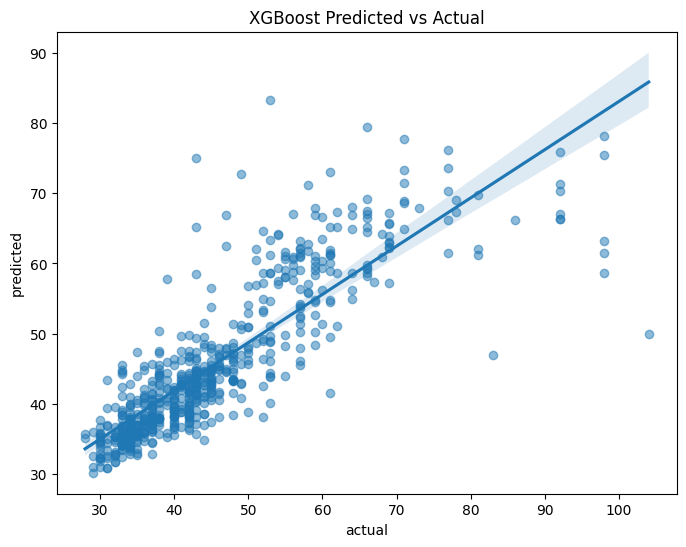

In [141]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_b, y_holdout_b)

R^2 Value of Holdout: 0.01
RMSE of Holdout: 7.94
Mean of Holdout: 45.55
This is 17.44% of the mean pheno data
0 42 49.26
1 42 44.428
2 32 35.966
3 56 56.166
4 32 39.262
5 48 43.958


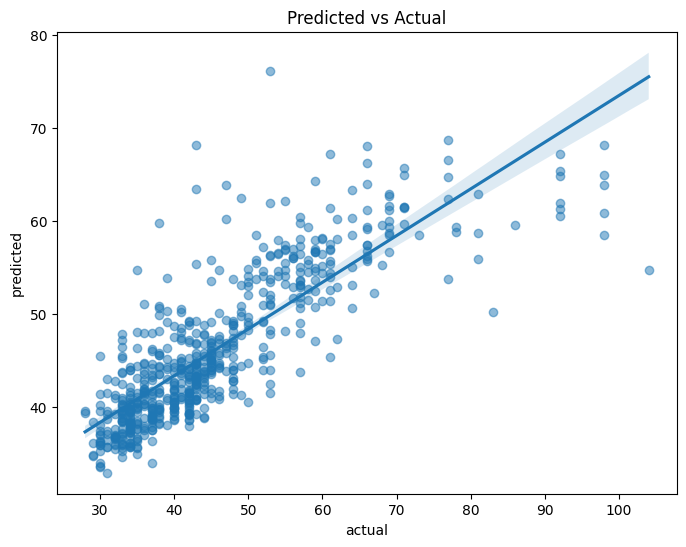

In [47]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_b, y_holdout_b)

R^2 Value of Holdout: 0.31
RMSE of Holdout: 7.92
Mean of Holdout: 45.55
This is 17.38% of the mean pheno data
0 42 40.11326328974037
1 42 52.8499089696922
2 32 31.182648488861282
3 56 62.42895021874455
4 32 34.54335046495061
5 48 44.17006529693453


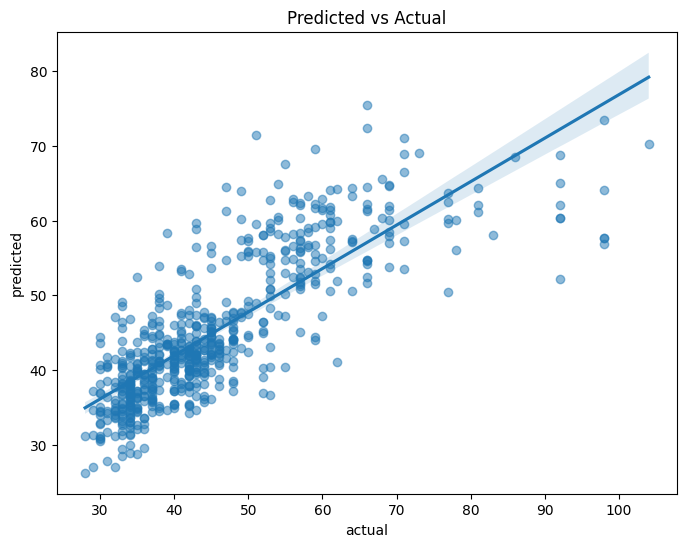

In [60]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_b, y_holdout_b)

In [148]:
explainer = shap.Explainer(best_xgbr_model)

In [197]:
explainer = shap.Explainer(best_rfr_model)

In [151]:
shap_values = explainer(X_dupe)

In [ ]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

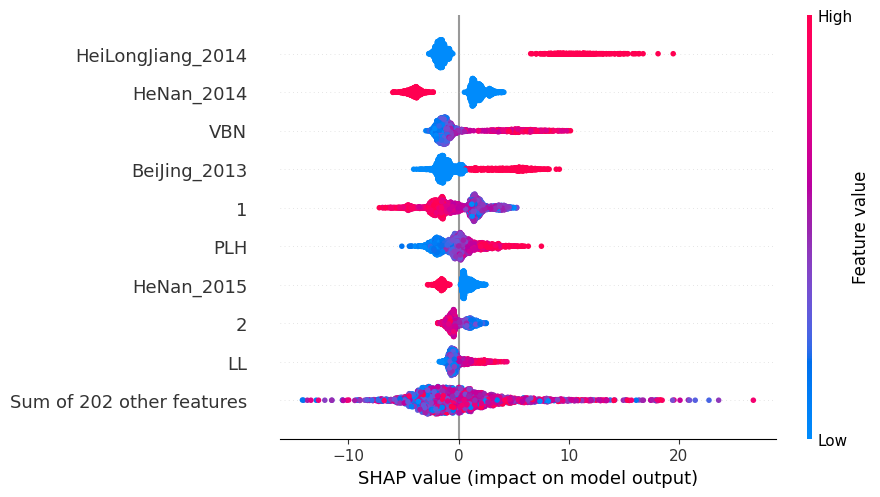

In [152]:
shap.plots.beeswarm(shap_values, show=False)

In [ ]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

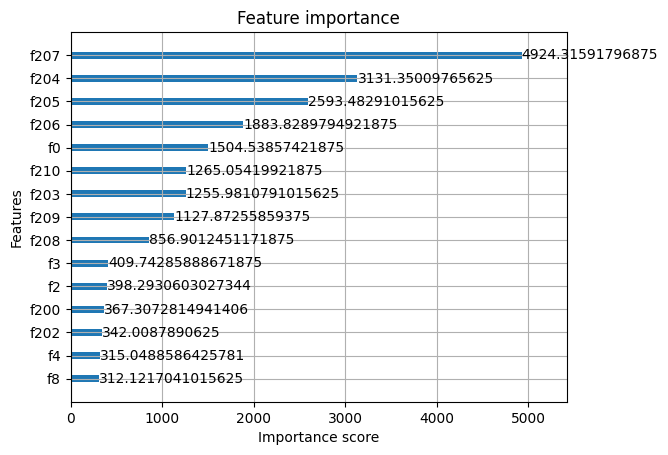

In [154]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

### Only location models 

In [61]:
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,-0.047794,0.025266,-0.001196,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.051694,0.007611,0.026473,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.029533,-0.009204,-0.021543,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.000290,0.000975,-0.025159,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.018123,0.015692,-0.035930,0,1,0,0,0,1,0


In [62]:
pca_loc.shape

(2536, 207)

In [67]:
y = pca_full_train_b.iloc[:, 511:]
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [68]:
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [69]:
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s2095 to s2095
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   BBD     2536 non-null   int64
dtypes: int64(1)
memory usage: 39.6+ KB


In [70]:
X_train, X_test, y_train, y_test = train_test_split(pca_loc, y, test_size=0.1, random_state=42)

In [71]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s751,0.034038,0.016873,0.028437,0.016985,0.041567,-0.011277,0.010893,-0.007294,0.021065,0.008683,...,-0.002998,0.020097,-0.015548,0,0,0,0,1,1,0
s2524,-0.013223,0.025331,-0.009614,-0.032212,-0.009424,0.028183,0.002461,-0.062745,-0.015255,0.060489,...,-0.014441,0.015679,-0.035519,0,0,1,0,0,1,0
s289,0.015411,0.021238,-0.029882,-0.010947,-0.000857,0.012313,-0.022897,0.059262,-0.011422,0.005761,...,0.031422,0.023683,0.005378,1,0,0,0,0,1,0
s2066,0.030777,0.005938,0.019736,0.033943,0.026909,-0.014807,-0.005942,-0.002904,0.009423,0.006739,...,-0.010601,0.007858,0.002511,0,0,0,1,0,1,0
s1514,0.016910,-0.011236,0.011807,0.040522,-0.060375,0.055395,0.025993,-0.013385,-0.048165,0.007167,...,0.019574,-0.029386,0.018514,0,1,0,0,0,0,1


In [72]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [123]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5095169684706893), ('colsample_bytree', 0.8941112919194393), ('gamma', 1.202805928133647e-06), ('learning_rate', 0.19004752142714143), ('max_delta_step', 17), ('max_depth', 8), ('min_child_weight', 6), ('n_estimators', 73), ('reg_alpha', 0.15254384514337754), ('reg_lambda', 5.893256574052616e-09), ('subsample', 1.0)])


In [ ]:
best_params = {'colsample_bylevel': 0.5095169684706893, 
               'colsample_bytree': 0.8941112919194393, 
               'gamma': 1.202805928133647e-06, 
               'learning_rate': 0.19004752142714143, 
               'max_delta_step': 17, 
               'max_depth': 8, 
               'min_child_weight': 6, 
               'n_estimators': 73, 
               'reg_alpha': 0.15254384514337754, 
               'reg_lambda': 5.893256574052616e-09, 
               'subsample': 1.0)
              }
#best_xgbreg = xgb.XGBRegressor(**best_params)

In [80]:
pca_loc = pca_loc.to_numpy()
y = y.to_numpy() 
#best_xgbr_model = eval_k_fold(best_xgbreg, pca_loc, y, 10)

In [125]:
pickle.dump(best_xgbr_model, open("pca_200_best_model_onlyloc_xgbr_bbd.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("pca_200_best_model_onlyloc_xgbr_bbd.pickle.dat", "rb"))

In [73]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [74]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [75]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout_b = pca_loc_dupe.align(X_holdout_b, join='inner', axis=1)

In [76]:
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,-0.076285,0.038883,0.008870,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,-0.014977,0.022092,-0.003266,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,0.041335,-0.001874,-0.028509,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,-0.016210,-0.016675,-0.058921,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,0.006450,0.025692,0.000965,0,1,0,0,0,1,0


In [77]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

R^2 Value of Holdout: 0.59
RMSE of Holdout: 6.96
Mean of Holdout: 45.55
This is 15.28% of the mean pheno data
0 42 44.726345
1 42 42.119526
2 32 29.801039
3 56 64.35408
4 32 35.224945
5 48 43.842518


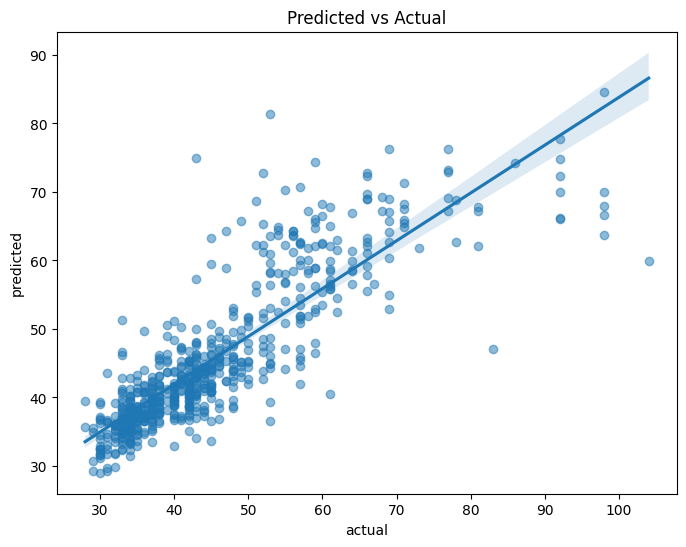

In [131]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_b, y_holdout_b)

In [132]:
explainer = shap.Explainer(best_xgbr_model)

In [133]:
shap_values = explainer(pca_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

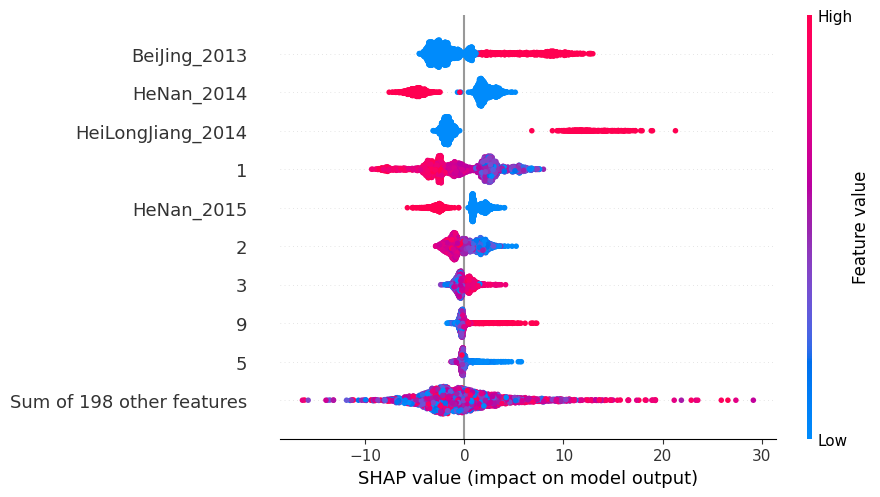

In [134]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

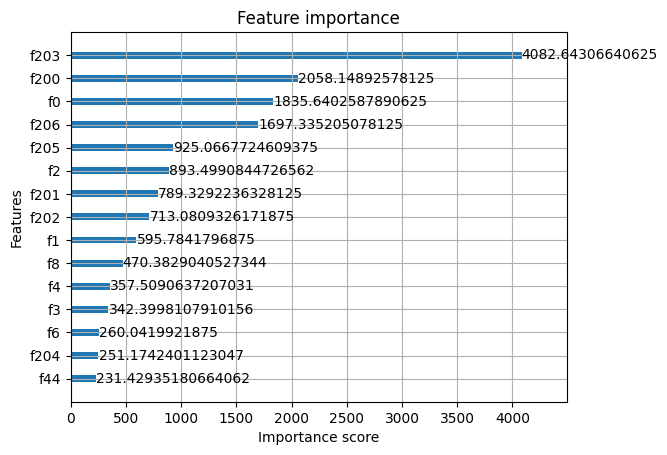

In [135]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [136]:
#### RF models

In [87]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 46), ('max_features', 'sqrt'), ('max_samples', 0.9688471693389253), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 347)])


In [88]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [ ]:
best_rfr_model =  OrderedDict([('bootstrap', True), 
                               ('max_depth', 23), 
                               ('max_features', 'sqrt'), 
                               ('max_samples', 1.0), 
                               ('min_samples_leaf', 1), 
                               ('min_samples_split', 2), 
                               ('n_estimators', 500)])

In [89]:
best_rfr_model = eval_k_fold(best_rfreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.07987508589157089
RMSE for dataset is:7.396756527742746& mean of this fold is 46.1496062992126
this is 16.027778178183393% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.4197489984467895
RMSE for dataset is:8.663410926053867& mean of this fold is 46.54330708661417
this is 18.613655686158708% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.38302096497904947
RMSE for dataset is:8.999940588373734& mean of this fold is 47.01574803149607
this is 19.142395825212933% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.08996680353593778
RMSE for dataset is:7.745059137204728& mean of this fold is 46.011811023622045
this is 16.83276307735091% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.0688250778215902
RMSE fo

In [90]:
best_svr_model = eval_k_fold(best_svreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.04738014893717368
RMSE for dataset is:9.073306249042153& mean of this fold is 46.65748031496063
this is 19.446627181307118% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.2129481673533764
RMSE for dataset is:9.365706001467665& mean of this fold is 45.87007874015748
this is 20.41789824369399% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.0910324721282253
RMSE for dataset is:8.921836666954146& mean of this fold is 46.38582677165354
this is 19.233971425957844% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.35801817612010156
RMSE for dataset is:9.945756969803035& mean of this fold is 46.42913385826772
this is 21.421370900788357% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.05284740684839773
RMSE for 

In [139]:
pickle.dump(best_rfr_model, open("pca_200_best_model_onlyloc_rfr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_200_best_model_onlyloc_rfr_bbd.pickle.dat", "rb"))

In [91]:
pickle.dump(best_svr_model, open("pca_200_best_model_onlyloc_svr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_200_best_model_onlyloc_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: -0.50
RMSE of Holdout: 8.75
Mean of Holdout: 45.55
This is 19.20% of the mean pheno data
0 42 50.325648414985594
1 42 42.268011527377524
2 32 36.221902017291065
3 56 56.97406340057637
4 32 39.783861671469744
5 48 45.36599423631124


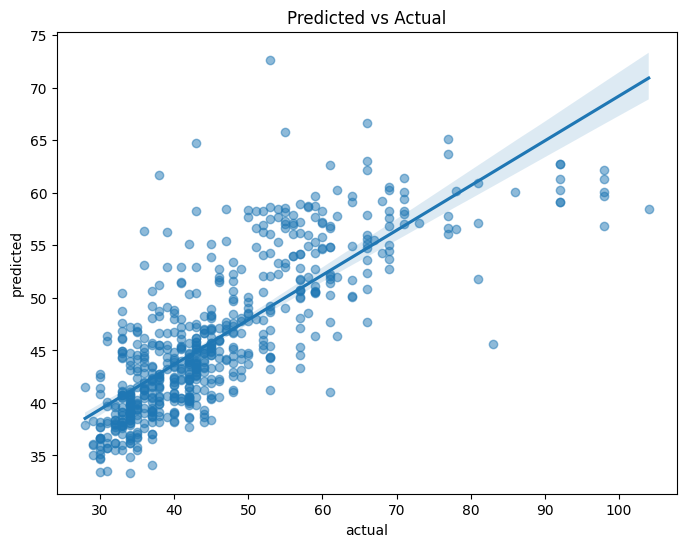

In [92]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_b, y_holdout_b)

R^2 Value of Holdout: -0.26
RMSE of Holdout: 9.43
Mean of Holdout: 45.55
This is 20.71% of the mean pheno data
0 42 39.26611806929589
1 42 42.5017604825222
2 32 36.13259282882021
3 56 58.398492119782816
4 32 37.08198796798915
5 48 40.6930610304262


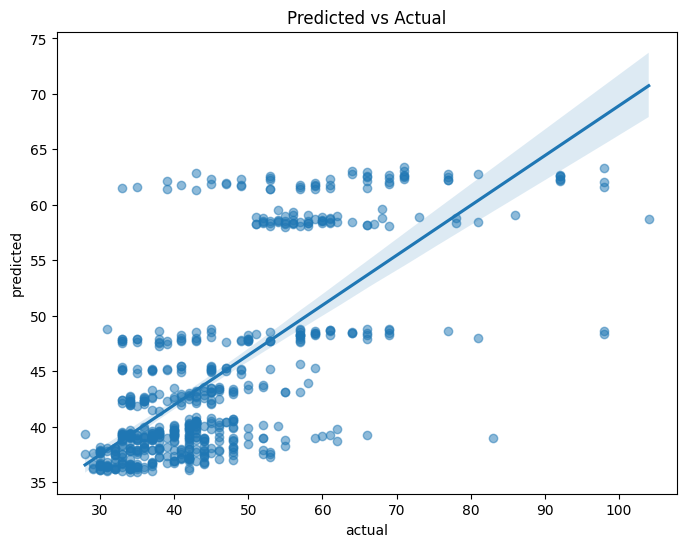

In [93]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_b, y_holdout_b)

### Only PCs

In [94]:
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.001748,0.049728,-0.004468,0.013603,0.004783,-0.047794,0.025266,-0.001196,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.003405,-0.035944,-0.020534,-0.005262,-0.004323,-0.051694,0.007611,0.026473,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.022575,0.000761,0.009345,-0.009807,0.022334,-0.029533,-0.009204,-0.021543,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.009625,-0.005164,0.002213,-0.000575,0.027361,0.000290,0.000975,-0.025159,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.036281,-0.008460,0.006966,-0.063939,-0.035466,-0.018123,0.015692,-0.035930,1,0


In [95]:
only_pca.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s2095 to s2095
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 3.9+ MB


In [159]:
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.001748,0.049728,-0.004468,0.013603,0.004783,-0.047794,0.025266,-0.001196,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.003405,-0.035944,-0.020534,-0.005262,-0.004323,-0.051694,0.007611,0.026473,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.022575,0.000761,0.009345,-0.009807,0.022334,-0.029533,-0.009204,-0.021543,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.009625,-0.005164,0.002213,-0.000575,0.027361,0.000290,0.000975,-0.025159,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.036281,-0.008460,0.006966,-0.063939,-0.035466,-0.018123,0.015692,-0.035930,1,0


In [96]:
y = pca_full_train_b.iloc[:, 511:]
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [97]:
y.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s2095 to s2095
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   BBD     2536 non-null   int64
dtypes: int64(1)
memory usage: 39.6+ KB


In [98]:
X_train, X_test, y_train, y_test = train_test_split(only_pca, y, test_size=0.1, random_state=42)

In [99]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s751,0.034038,0.016873,0.028437,0.016985,0.041567,-0.011277,0.010893,-0.007294,0.021065,0.008683,...,-0.014090,0.004667,-0.013260,0.010214,-0.017785,-0.002998,0.020097,-0.015548,1,0
s2524,-0.013223,0.025331,-0.009614,-0.032212,-0.009424,0.028183,0.002461,-0.062745,-0.015255,0.060489,...,0.005511,0.031917,-0.005540,-0.012087,-0.011267,-0.014441,0.015679,-0.035519,1,0
s289,0.015411,0.021238,-0.029882,-0.010947,-0.000857,0.012313,-0.022897,0.059262,-0.011422,0.005761,...,-0.006297,0.008536,-0.028209,0.005999,0.003828,0.031422,0.023683,0.005378,1,0
s2066,0.030777,0.005938,0.019736,0.033943,0.026909,-0.014807,-0.005942,-0.002904,0.009423,0.006739,...,0.008174,-0.002433,0.013403,0.010279,0.033422,-0.010601,0.007858,0.002511,1,0
s1514,0.016910,-0.011236,0.011807,0.040522,-0.060375,0.055395,0.025993,-0.013385,-0.048165,0.007167,...,-0.024408,-0.036032,-0.065706,0.041519,0.036007,0.019574,-0.029386,0.018514,0,1


In [100]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [165]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])


In [ ]:
OrderedDict([('colsample_bylevel', 0.14638413202022832), ('colsample_bytree', 0.12268563166303768), ('gamma', 0.003272909619989833), ('learning_rate', 0.04299471176755962), ('max_delta_step', 13), ('max_depth', 1), ('min_child_weight', 3), ('n_estimators', 187), ('reg_alpha', 0.7519510777663355), ('reg_lambda', 1.0193603023879012e-05), ('subsample', 0.25155383002194887)])

In [101]:
only_pca = only_pca.to_numpy()
y = y.to_numpy() 
#best_xgbr_model = eval_k_fold(best_xgbreg, only_pca, y, 10)

In [167]:
pickle.dump(best_xgbr_model, open("pca_200_best_model_onlypcs_xgbr_bbd.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("pca_200_best_model_onlypcs_xgbr_bbd.pickle.dat", "rb"))

In [102]:
pca_full_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [103]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [104]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [105]:
# Ensure both training and holdout datasets have the same columns
only_pca_dupe, X_holdout_b = only_pca_dupe.align(X_holdout_b, join='inner', axis=1)

In [106]:
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,0.027130,0.025326,0.038300,0.037385,0.005399,-0.076285,0.038883,0.008870,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,0.031241,0.035267,-0.023999,-0.010887,-0.009411,-0.014977,0.022092,-0.003266,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,0.048796,-0.036901,-0.001493,-0.005935,-0.008459,0.041335,-0.001874,-0.028509,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,-0.006383,0.002932,-0.040869,-0.040520,-0.003248,-0.016210,-0.016675,-0.058921,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,0.010848,-0.058367,0.007001,-0.013180,-0.017305,0.006450,0.025692,0.000965,1,0


In [107]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

R^2 Value of Holdout: -27.74
RMSE of Holdout: 12.69
Mean of Holdout: 45.55
This is 27.86% of the mean pheno data
0 42 53.36778
1 42 45.368652
2 32 45.301865
3 56 44.742393
4 32 48.819958
5 48 46.810837


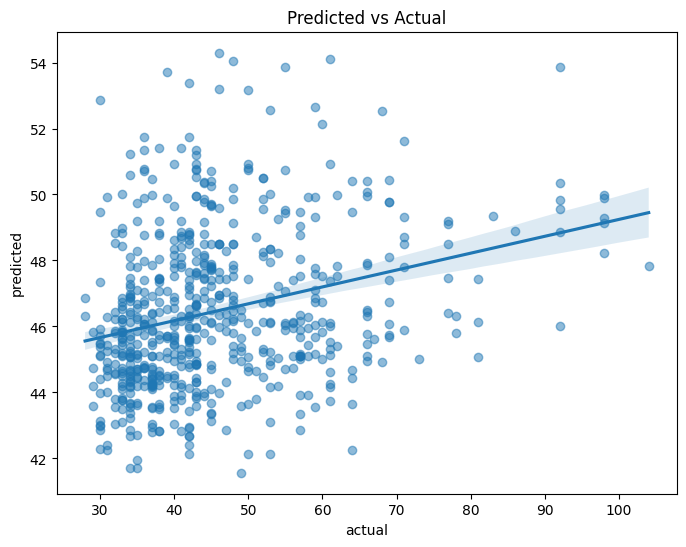

In [181]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_b, y_holdout_b)

In [ ]:
#### RF Models

In [182]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 7), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 489)])


In [110]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2), ('kernel', 'poly')])


In [ ]:
OrderedDict([('bootstrap', True), ('max_depth', 7), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 10), ('min_samples_split', 20), ('n_estimators', 489)])

In [183]:
best_rfr_model = eval_k_fold(best_rfreg, only_pca, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -17.056660792693005
RMSE for dataset is:12.867167854739424& mean of this fold is 46.72047244094488
this is 27.540748589397605% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -15.742130020666025
RMSE for dataset is:13.722940880898614& mean of this fold is 46.59448818897638
this is 29.451854531037156% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -14.926247669873629
RMSE for dataset is:13.578651190706246& mean of this fold is 47.52755905511811
this is 28.570058005627786% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -12.008636777319643
RMSE for dataset is:11.707309222495567& mean of this fold is 47.169291338582674
this is 24.819769155445073% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -12.444515996161998
RMSE

In [111]:
best_svr_model = eval_k_fold(best_svreg, only_pca, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -49.3768008554021
RMSE for dataset is:14.11000555334198& mean of this fold is 47.44488188976378
this is 29.739784337804853% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -44.34630783704419
RMSE for dataset is:13.143099406735493& mean of this fold is 46.06299212598425
this is 28.53288247274201% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -43.384564197056584
RMSE for dataset is:11.978798891288795& mean of this fold is 45.32283464566929
this is 26.42994195958438% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -47.24582195722012
RMSE for dataset is:14.058558042126025& mean of this fold is 47.86614173228347
this is 29.37056870126674% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -44.872230838739036
RMSE for data

In [184]:
pickle.dump(best_rfr_model, open("pca_200_best_model_onlypcs_rfr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_200_best_model_onlypcs_rfr_bbd.pickle.dat", "rb"))

In [112]:
pickle.dump(best_svr_model, open("pca_200_best_model_onlypcs_svr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_200_best_model_onlypcs_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: -11.81
RMSE of Holdout: 12.64
Mean of Holdout: 45.55
This is 27.76% of the mean pheno data
0 42 55.71208041416465
1 42 46.219332245917435
2 32 44.695587081905586
3 56 45.52737234625886
4 32 46.15000797714554
5 48 46.78464186003147


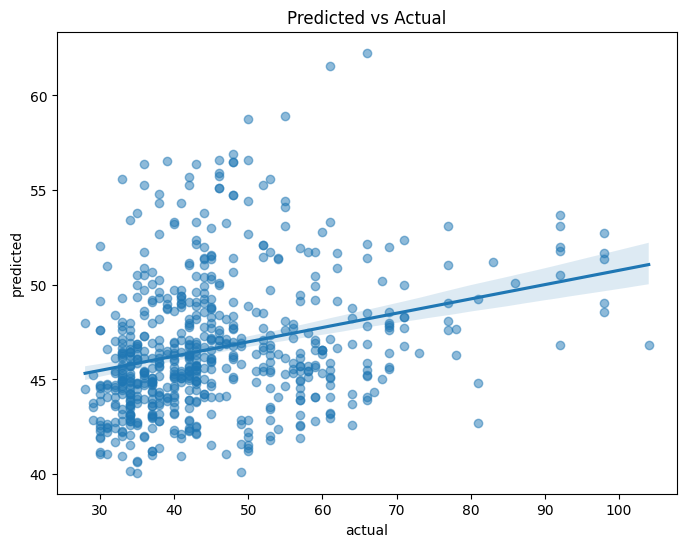

In [185]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_b, y_holdout_b)

R^2 Value of Holdout: -43.50
RMSE of Holdout: 13.03
Mean of Holdout: 45.55
This is 28.59% of the mean pheno data
0 42 47.630750832498435
1 42 44.14302043875305
2 32 41.222132674181076
3 56 42.02823739464847
4 32 41.26786634226405
5 48 43.19641335251745


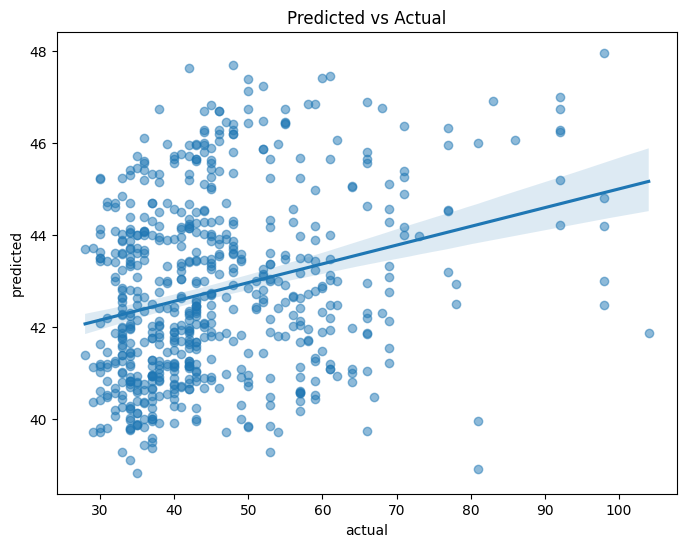

In [113]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_b, y_holdout_b)

# PC500 models

In [114]:
y = pca_full_train_b.iloc[:, 511:]
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [115]:
X = pca_full_train_b.iloc[:, 0:511]
X.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [116]:
X_dupe = pca_full_train_b.iloc[:, 0:511]
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [118]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [ ]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

In [97]:

best_params = {
    'colsample_bylevel': 0.16975074821232053,
    'colsample_bytree': 0.7700635638092945,
    'gamma': 0.49999999999999994,
    'learning_rate': 0.08281369575374707,
    'max_delta_step': 20,
    'max_depth': 4,
    'min_child_weight': 2,
    'n_estimators': 200,
    'reg_alpha': 1.3998058433748922e-09,
    'reg_lambda': 6.998838349296903,
    'subsample': 0.9094311201012985
}
best_xgbreg = xgb.XGBRegressor(**best_params)

In [119]:
X = X.to_numpy()
y = y.to_numpy() 
#best_xgbr_model = eval_k_fold(best_xgbreg, X, y, 10)

In [100]:
pickle.dump(best_xgbr_model, open("pca_500_best_model_allfeats_xgbr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_allfeats_xgbr_bbd.pickle.dat", "rb"))

In [120]:
X_holdout_b = pca_full_holdout_b.iloc[:, 0:511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [121]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [122]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout_b = X_dupe.align(X_holdout_b, join='inner', axis=1)

In [123]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

R^2 Value of Holdout: 0.60
RMSE of Holdout: 6.85
Mean of Holdout: 45.55
This is 15.03% of the mean pheno data
0 42 49.401085
1 42 42.54959
2 32 32.409245
3 56 59.708187
4 32 37.017273
5 48 45.512524


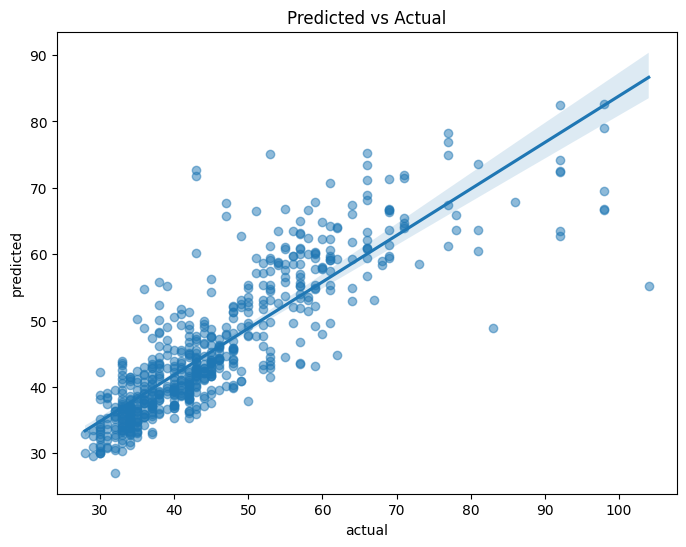

In [105]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_b, y_holdout_b)

In [180]:
explainer = shap.Explainer(best_xgbr_model)

In [181]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

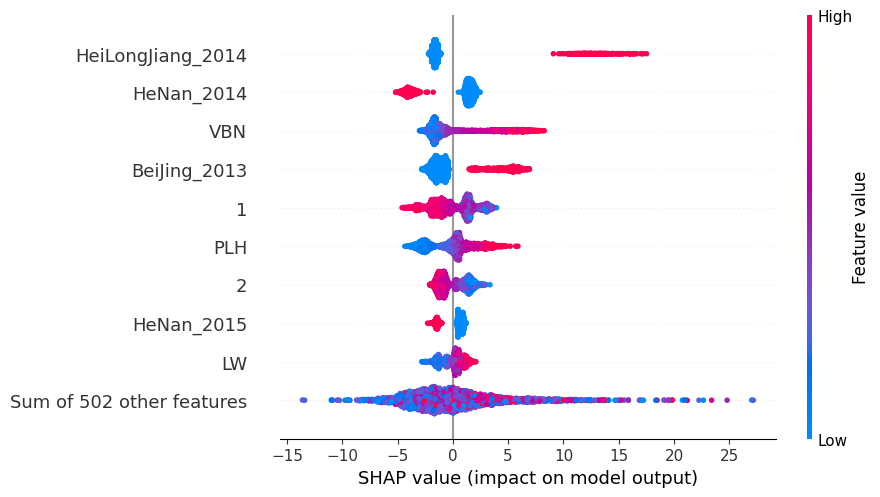

In [182]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

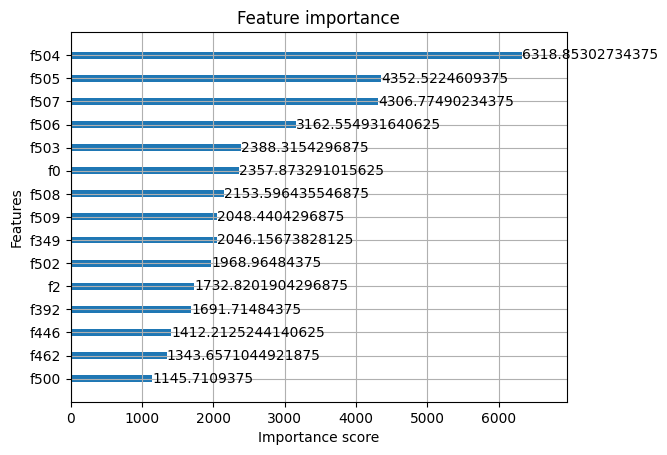

In [183]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [22]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [124]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [ ]:
#best_rfreg = OrderedDict([('bootstrap', True), 
                          ('max_depth', 50), 
                          ('max_features', 'sqrt'), 
                          ('max_samples', 1.0), 
                          ('min_samples_leaf', 1), 
                          ('min_samples_split', 2), 
                          ('n_estimators', 500)])

In [24]:
X = X.to_numpy()
y = y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.8569090683714495
RMSE for dataset is:9.04341484305691& mean of this fold is 46.44094488188976
this is 19.47293464001742% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.18275105267094838
RMSE for dataset is:8.10799639242412& mean of this fold is 46.6496062992126
this is 17.38063198308487% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.7956073890945945
RMSE for dataset is:9.094566921444166& mean of this fold is 47.59842519685039
this is 19.106865161677568% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.627531607898532
RMSE for dataset is:8.457826788225955& mean of this fold is 45.488188976377955
this is 18.59345684792619% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5985667568916357
RMSE for datas

In [125]:
best_svr_model = eval_k_fold(best_svreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3579821851199143
RMSE for dataset is:7.494403126798713& mean of this fold is 45.40551181102362
this is 16.505492016013815% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.19370411171817958
RMSE for dataset is:8.178567152455408& mean of this fold is 46.11417322834646
this is 17.73547388989732% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.16907018987553546
RMSE for dataset is:8.33878618688131& mean of this fold is 46.925196850393704
this is 17.770380832853867% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3634511360337327
RMSE for dataset is:7.598138263153208& mean of this fold is 46.13385826771653
this is 16.469765479099806% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.4172632798168856
RMSE for data

In [25]:
pickle.dump(best_rfr_model, open("pca_500_best_model_allfeats_rfr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_allfeats_rfr_bbd.pickle.dat", "rb"))

In [126]:
pickle.dump(best_svr_model, open("pca_500_best_model_allfeats_svr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_allfeats_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: -0.61
RMSE of Holdout: 8.99
Mean of Holdout: 45.55
This is 19.73% of the mean pheno data
0 42 51.938
1 42 45.51
2 32 36.504
3 56 55.756
4 32 42.301333333333325
5 48 44.64


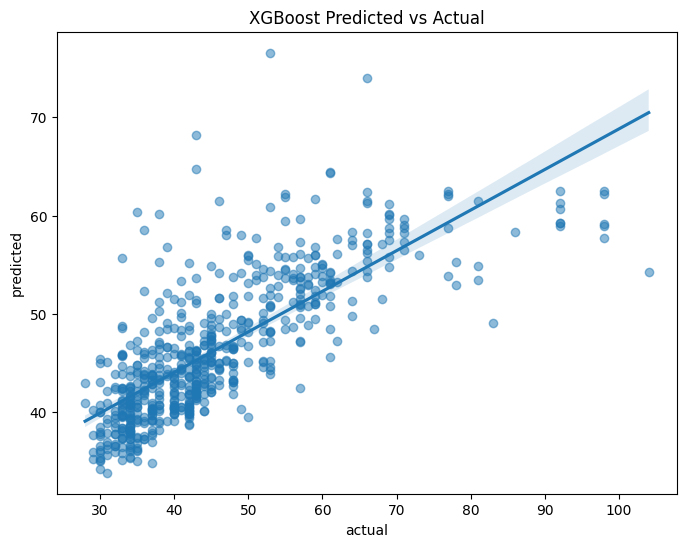

In [30]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_b, y_holdout_b)

R^2 Value of Holdout: 0.29
RMSE of Holdout: 7.90
Mean of Holdout: 45.55
This is 17.33% of the mean pheno data
0 42 39.67419828980489
1 42 53.43097948186657
2 32 31.941241732022874
3 56 62.42087525411914
4 32 34.793772245528245
5 48 44.6907936292602


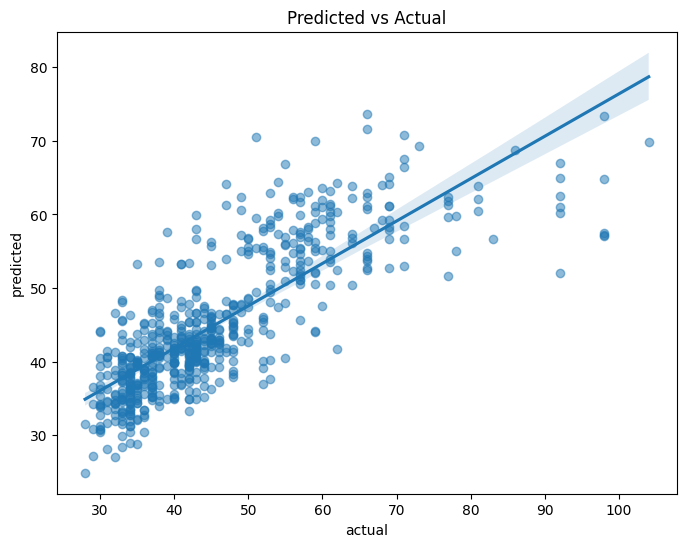

In [127]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_b, y_holdout_b)

In [32]:
explainer = shap.Explainer(best_rfr_model)

In [ ]:
shap_values = explainer(X_dupe)

In [ ]:
shap.plots.beeswarm(shap_values, show=False)

### Only location Models

In [129]:
pca_loc= X_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.010562,-0.020318,0.010057,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,0.056979,0.020866,0.000859,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.015515,-0.018886,0.011926,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.017881,-0.002570,0.001820,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.006503,-0.019643,-0.008418,0,1,0,0,0,1,0


In [130]:
pca_loc_dupe = X_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.010562,-0.020318,0.010057,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,0.056979,0.020866,0.000859,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.015515,-0.018886,0.011926,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.017881,-0.002570,0.001820,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.006503,-0.019643,-0.008418,0,1,0,0,0,1,0


In [131]:
y = pca_full_train_b.iloc[:, 511:]
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [132]:
X_train, X_test, y_train, y_test = train_test_split(pca_loc, y, test_size=0.1, random_state=42)

In [133]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [193]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])


In [ ]:
OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 4), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('subsample', 0.5544643023916863)])

In [142]:
pca_loc = pca_loc.to_numpy()
y = y.to_numpy() 
#best_xgbr_model = eval_k_fold(best_xgbreg, pca_loc, y, 10)

In [195]:
pickle.dump(best_xgbr_model, open("pca_500_best_model_onlyloc_xgbr_bbd.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("pca_500_best_model_onlyloc_xgbr_bbd.pickle.dat", "rb"))

In [134]:
pca_full_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [135]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [136]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [137]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout_b = pca_loc_dupe.align(X_holdout_b, join='inner', axis=1)

In [138]:
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,-0.029445,-0.041585,-0.040469,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,0.066243,0.023875,0.041942,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,-0.007096,0.015815,-0.020782,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,0.024603,-0.015158,0.004522,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,0.002058,-0.012293,0.012375,0,1,0,0,0,1,0


In [139]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

R^2 Value of Holdout: 0.47
RMSE of Holdout: 7.22
Mean of Holdout: 45.55
This is 15.85% of the mean pheno data
0 42 38.77843
1 42 43.67495
2 32 32.24014
3 56 61.11477
4 32 38.643806
5 48 44.55217


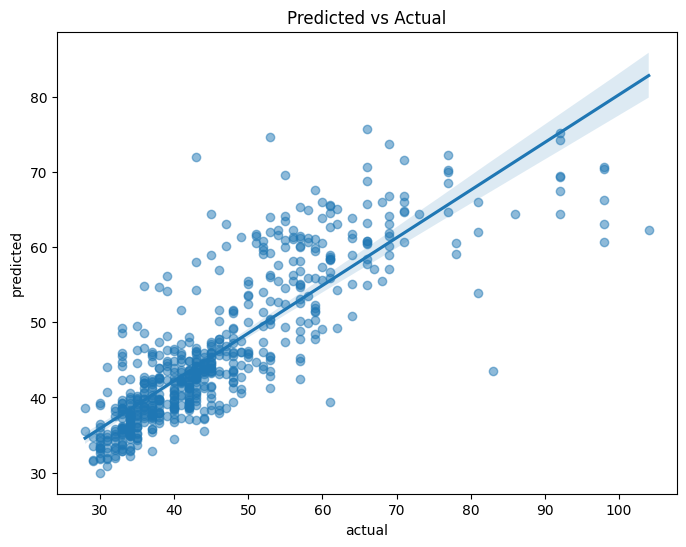

In [203]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_b, y_holdout_b)

In [204]:
explainer = shap.Explainer(best_xgbr_model)

In [206]:
shap_values = explainer(pca_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

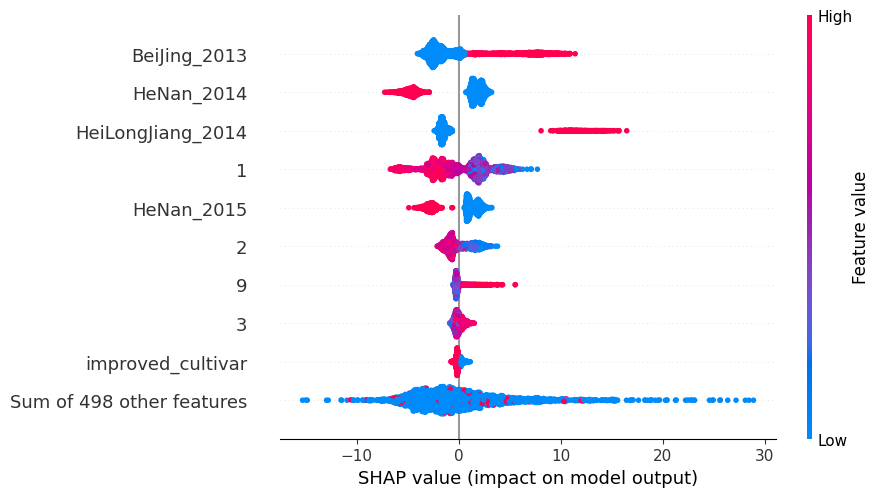

In [207]:
shap.plots.beeswarm(shap_values, show=False)

In [ ]:
#### RF Models

In [208]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 32), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 50)])


In [140]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [ ]:
OrderedDict([('bootstrap', True), ('max_depth', 32), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 50)])


In [209]:
best_rfr_model = eval_k_fold(best_rfreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.386054071573895
RMSE for dataset is:10.128766254432081& mean of this fold is 47.29133858267716
this is 21.41780410111346% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.0337959860963295
RMSE for dataset is:9.781444825756108& mean of this fold is 47.24409448818898
this is 20.704058214517094% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.4214118160283644
RMSE for dataset is:9.76889828071378& mean of this fold is 46.89370078740158
this is 20.832005400900847% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.7415176406547674
RMSE for dataset is:10.365784296222957& mean of this fold is 46.24015748031496
this is 22.417277234913843% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.1299340157103668
RMSE for d

In [143]:
best_svr_model = eval_k_fold(best_svreg, pca_loc, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.04676405725739352
RMSE for dataset is:8.677639780481618& mean of this fold is 47.653543307086615
this is 18.209852150052306% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.11994006578640537
RMSE for dataset is:8.970725593961372& mean of this fold is 46.145669291338585
this is 19.440016217611028% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.09355392545566432
RMSE for dataset is:9.341065860231234& mean of this fold is 46.90944881889764
this is 19.91297296264149% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.31714061818024963
RMSE for dataset is:9.308312450003825& mean of this fold is 46.28740157480315
this is 20.109818510682757% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.14245230769001682
RMSE

In [210]:
pickle.dump(best_rfr_model, open("pca_500_best_model_onlyloc_rfr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_onlyloc_rfr_bbd.pickle.dat", "rb"))

In [144]:
pickle.dump(best_svr_model, open("pca_500_best_model_onlyloc_svr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_onlyloc_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: -0.97
RMSE of Holdout: 9.80
Mean of Holdout: 45.55
This is 21.51% of the mean pheno data
0 42 51.24
1 42 46.96
2 32 35.8
3 56 56.02
4 32 41.3
5 48 44.44


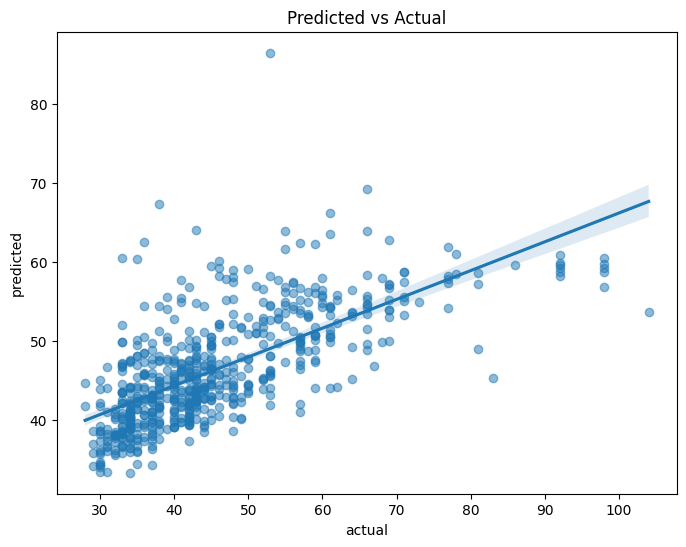

In [211]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_b, y_holdout_b)

R^2 Value of Holdout: -0.29
RMSE of Holdout: 9.40
Mean of Holdout: 45.55
This is 20.63% of the mean pheno data
0 42 39.99927708483229
1 42 42.70125969734944
2 32 36.98329877690887
3 56 59.0149606172431
4 32 37.65622023399759
5 48 40.42148259693467


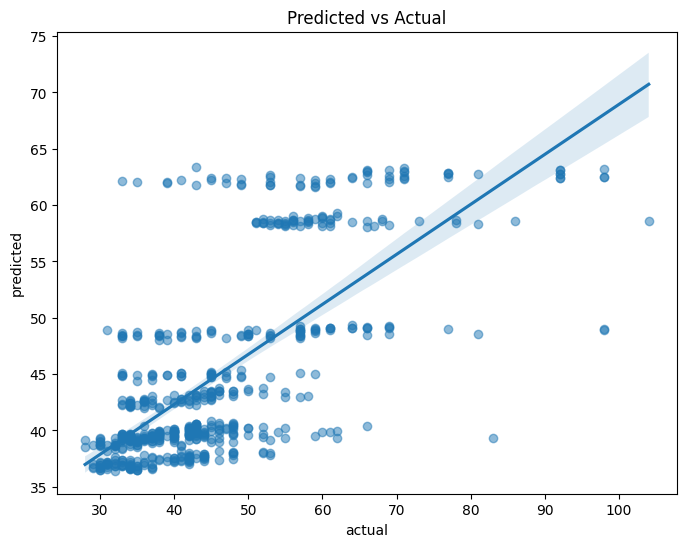

In [145]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_b, y_holdout_b)

### Only PCs models

In [146]:
y = pca_full_train_b.iloc[:, 511:]
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [147]:
pca_only =  pca_full_train_b.iloc[:, :500]
pca_only.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.036188,-0.077684,-0.104369,0.027982,0.055085,-0.011344,0.058702,0.010562,-0.020318,0.010057
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.049191,-0.017708,0.011400,-0.044449,-0.030079,-0.031201,0.065441,0.056979,0.020866,0.000859
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,0.019115,0.019405,-0.015551,-0.003208,0.005062,-0.002142,0.020824,-0.015515,-0.018886,0.011926
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.007118,-0.003867,-0.004491,0.003115,-0.000937,-0.008987,-0.003813,-0.017881,-0.002570,0.001820
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.001331,-0.036815,0.004882,-0.035451,-0.020030,0.027865,-0.004135,-0.006503,-0.019643,-0.008418


In [148]:
pca_only_dupe =  pca_full_train_b.iloc[:, :500]
pca_only_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.036188,-0.077684,-0.104369,0.027982,0.055085,-0.011344,0.058702,0.010562,-0.020318,0.010057
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.049191,-0.017708,0.011400,-0.044449,-0.030079,-0.031201,0.065441,0.056979,0.020866,0.000859
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,0.019115,0.019405,-0.015551,-0.003208,0.005062,-0.002142,0.020824,-0.015515,-0.018886,0.011926
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.007118,-0.003867,-0.004491,0.003115,-0.000937,-0.008987,-0.003813,-0.017881,-0.002570,0.001820
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.001331,-0.036815,0.004882,-0.035451,-0.020030,0.027865,-0.004135,-0.006503,-0.019643,-0.008418


In [149]:
X_train, X_test, y_train, y_test = train_test_split(pca_only, y, test_size=0.1, random_state=42)

In [150]:
X_train.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s751,0.034038,0.016873,0.028437,0.016985,0.041567,-0.011277,0.010893,-0.007294,0.021065,0.008683,...,-0.033414,0.045027,0.008794,-0.000083,0.013858,-0.026745,-0.040849,-0.054082,-0.031675,-0.063357
s2524,-0.013223,0.025331,-0.009614,-0.032212,-0.009424,0.028183,0.002461,-0.062745,-0.015255,0.060489,...,0.016221,0.002552,-0.000909,0.020312,0.026968,-0.044621,0.009320,0.007733,-0.005183,0.010375
s289,0.015411,0.021238,-0.029882,-0.010947,-0.000857,0.012313,-0.022897,0.059262,-0.011422,0.005761,...,0.046997,0.003245,0.046019,-0.017225,-0.004342,0.013806,-0.045570,-0.021032,-0.027634,-0.020041
s2066,0.030777,0.005938,0.019736,0.033943,0.026909,-0.014807,-0.005942,-0.002904,0.009423,0.006739,...,0.000582,0.039148,-0.007633,-0.046291,0.053032,0.050300,0.009954,-0.023510,0.041872,-0.024434
s1514,0.016910,-0.011236,0.011807,0.040522,-0.060375,0.055395,0.025993,-0.013385,-0.048165,0.007167,...,0.013143,-0.008205,0.032841,-0.004187,-0.005846,-0.014175,-0.001098,-0.003825,0.002713,-0.022860


In [151]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [217]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 0.859254676398978), ('gamma', 0.49999999999999994), ('learning_rate', 0.9903668402204833), ('max_delta_step', 17), ('max_depth', 1), ('min_child_weight', 9), ('n_estimators', 50), ('reg_alpha', 0.006537665554054858), ('reg_lambda', 1000.0), ('subsample', 1.0)])


In [ ]:
OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 0.859254676398978), ('gamma', 0.49999999999999994), ('learning_rate', 0.9903668402204833), ('max_delta_step', 17), ('max_depth', 1), ('min_child_weight', 9), ('n_estimators', 50), ('reg_alpha', 0.006537665554054858), ('reg_lambda', 1000.0), ('subsample', 1.0)])

In [218]:
pca_only = pca_only.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.853040732083464
RMSE for dataset is:12.636264662617434& mean of this fold is 47.468503937007874
this is 26.6203137124063% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.305933091097932
RMSE for dataset is:12.669335064029996& mean of this fold is 46.78740157480315
this is 27.078518228404736% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.361104440486203
RMSE for dataset is:12.126626517226647& mean of this fold is 45.818897637795274
this is 26.466430102900574% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.162210982817594
RMSE for dataset is:13.035386449299313& mean of this fold is 46.20866141732284
this is 28.209833501934273% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -6.511889619715893
RMSE for d

In [219]:
pickle.dump(best_xgbr_model, open("pca_500_best_model_onlypcs_xgbr_bbd.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("pca_500_best_model_onlypcs_xgbr_bbd.pickle.dat", "rb"))

In [152]:
pca_full_holdout_b.head()


,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [153]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [154]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [155]:
# Ensure both training and holdout datasets have the same columns
pca_only_dupe, X_holdout_b = pca_only_dupe.align(X_holdout_b, join='inner', axis=1)

In [156]:
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,0.021674,-0.055027,-0.066337,0.005896,-0.076011,-0.009170,-0.030699,-0.029445,-0.041585,-0.040469
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,-0.005329,-0.058498,0.018302,0.067772,0.013293,-0.060472,-0.079106,0.066243,0.023875,0.041942
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,-0.006045,-0.008649,0.006871,-0.039832,0.013795,-0.023307,0.026420,-0.007096,0.015815,-0.020782
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,0.000179,-0.010749,-0.027348,-0.046915,0.022335,-0.025496,-0.049090,0.024603,-0.015158,0.004522
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,0.004429,0.020245,0.000610,-0.033639,-0.008172,0.038090,-0.045679,0.002058,-0.012293,0.012375


In [157]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

R^2 Value of Holdout: -5.83
RMSE of Holdout: 12.46
Mean of Holdout: 45.55
This is 27.36% of the mean pheno data
0 42 53.625587
1 42 45.46017
2 32 46.526966
3 56 46.480812
4 32 45.908382
5 48 47.457394


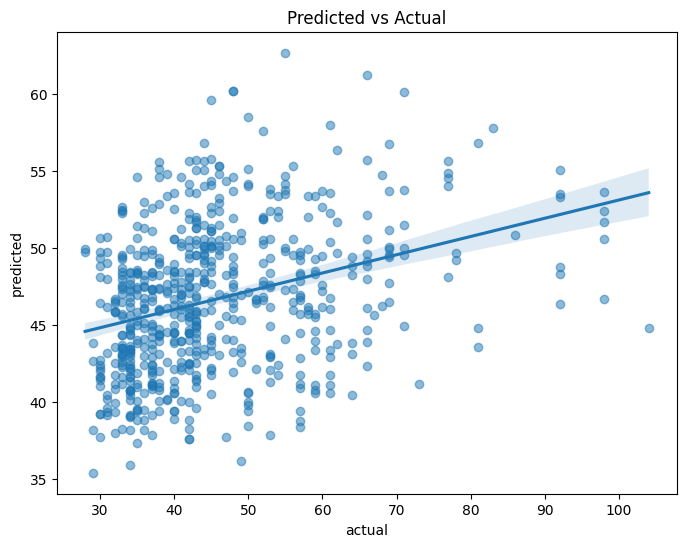

In [238]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_b, y_holdout_b)

#### RF Models

In [236]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5363732928880172), ('min_samples_leaf', 9), ('min_samples_split', 20), ('n_estimators', 500)])


In [158]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 3), ('kernel', 'rbf')])


In [ ]:
OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.5363732928880172), ('min_samples_leaf', 9), ('min_samples_split', 20), ('n_estimators', 500)])

In [239]:
best_rfr_model = eval_k_fold(best_rfreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.063474456051017
RMSE for dataset is:13.451172501841716& mean of this fold is 47.48031496062992
this is 28.329998469882224% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.725139207652274
RMSE for dataset is:12.602782194006869& mean of this fold is 47.13385826771653
this is 26.738278293332314% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.961360575652645
RMSE for dataset is:13.16559436085128& mean of this fold is 46.460629921259844
this is 28.337098276893695% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.683323895173467
RMSE for dataset is:12.346888133739567& mean of this fold is 45.22047244094488
this is 27.303757495819692% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.765880948025105
RMSE fo

In [159]:
pca_only = pca_only.to_numpy()
y = y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, pca_only, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -44.01252564848712
RMSE for dataset is:13.073434770461224& mean of this fold is 46.56299212598425
this is 28.07687859725333% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -32.82751903524327
RMSE for dataset is:11.645079546433502& mean of this fold is 45.8503937007874
this is 25.397992484922803% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -52.40519236116419
RMSE for dataset is:15.071127099141318& mean of this fold is 47.54724409448819
this is 31.697162235504635% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -31.686868760309068
RMSE for dataset is:12.351840213160667& mean of this fold is 46.44488188976378
this is 26.594620786155883% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -39.2387948683456
RMSE for dat

In [240]:
pickle.dump(best_rfr_model, open("pca_500_best_model_onlypcs_rfr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_onlypcs_rfr_bbd.pickle.dat", "rb"))

In [160]:
pickle.dump(best_svr_model, open("pca_500_best_model_onlypcs_svr_bbd.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_onlypcs_rfr_bbd.pickle.dat", "rb"))

R^2 Value of Holdout: -9.67
RMSE of Holdout: 12.80
Mean of Holdout: 45.55
This is 28.09% of the mean pheno data
0 42 55.134849887638296
1 42 48.89697219371193
2 32 43.713717576304916
3 56 48.22812435987205
4 32 47.83594387887243
5 48 46.95008018661883


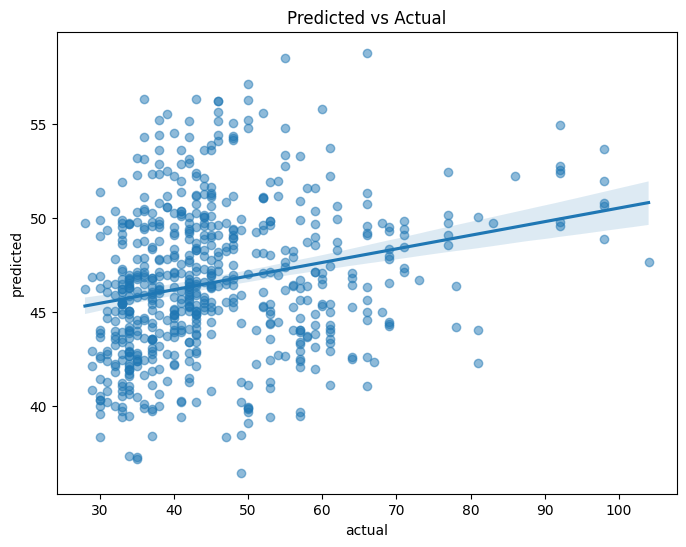

In [241]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_b, y_holdout_b)

R^2 Value of Holdout: -37.42
RMSE of Holdout: 12.97
Mean of Holdout: 45.55
This is 28.47% of the mean pheno data
0 42 46.76826979137471
1 42 44.38350836388053
2 32 42.90954483450469
3 56 44.0003820682012
4 32 44.010655957406165
5 48 44.808763373969974


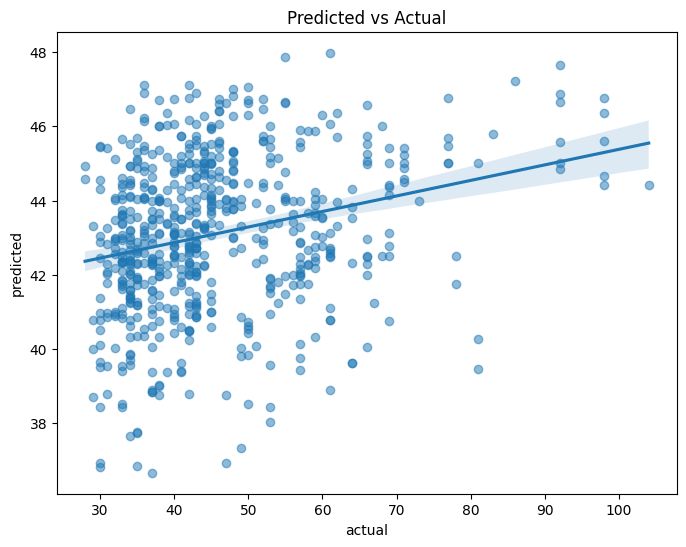

In [161]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_b, y_holdout_b)

# Maturity Date (MD) models

## Load and process the data

In [162]:
pca_full_train_m = pd.read_pickle("pickle_files/pca_full_training_md.pkl")

In [163]:
pca_full_train_m = pca_full_train_m.reset_index().set_index('Line')
pca_full_train_m = pca_full_train_m.drop(['index','new_line'], axis=1)
pca_full_train_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,43.9333,5.33333,1,0,0,0,0,0,1,113.0
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,83.2000,1.40000,0,0,1,0,0,1,0,107.0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,60.8000,3.80000,0,0,1,0,0,1,0,100.0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,67.0000,0.80000,0,1,0,0,0,1,0,103.0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,79.0000,1.00000,0,1,0,0,0,1,0,103.0


In [164]:
pca_full_holdout_m = pd.read_pickle("pickle_files/pca_full_holdout_md.pkl")

In [165]:
pca_full_holdout_m = pca_full_holdout_m.reset_index().set_index('Line')
pca_full_holdout_m = pca_full_holdout_m.drop(['index','new_line'], axis=1)
pca_full_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


## PC200 Models

In [166]:
X = pd.concat([pca_full_train_m.iloc[:, :200], pca_full_train_m.iloc[:, -12:]], axis=1)
X = X.drop(['MD'], axis=1)
X.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [167]:
X_dupe = pd.concat([pca_full_train_m.iloc[:, :200], pca_full_train_m.iloc[:, -12:]], axis=1)
X_dupe = X_dupe.drop(['MD'], axis=1)
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [168]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2450 entries, s503 to s2236
Columns: 211 entries, 1 to landrace
dtypes: float64(204), int64(7)
memory usage: 4.0+ MB


In [169]:
y = pca_full_train_m.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [170]:
pca_loc= X.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.003579,-0.081070,0.030498,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.001273,0.016743,0.025923,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.001582,0.006455,-0.010067,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.022296,0.007699,-0.011343,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.052144,0.060825,0.051451,0,1,0,0,0,1,0


In [171]:
pca_loc_dupe = X.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,-0.003579,-0.081070,0.030498,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.001273,0.016743,0.025923,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,0.001582,0.006455,-0.010067,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.022296,0.007699,-0.011343,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.052144,0.060825,0.051451,0,1,0,0,0,1,0


In [172]:
only_pca= pd.concat([pca_full_train_m.iloc[:, :200], pca_full_train_m.iloc[:, -3:]], axis=1)
only_pca= only_pca.drop(['MD'], axis=1)
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,0.000610,0.020551,0.029000,-0.032989,0.020069,-0.003579,-0.081070,0.030498,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.004685,-0.021917,0.005822,0.029612,0.060264,-0.001273,0.016743,0.025923,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.000054,0.011717,-0.001412,0.008280,-0.023776,0.001582,0.006455,-0.010067,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.039625,-0.011997,-0.002396,0.006086,0.001528,0.022296,0.007699,-0.011343,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.054112,-0.037200,-0.008555,-0.018565,0.053066,-0.052144,0.060825,0.051451,1,0


In [173]:
only_pca_dupe= pd.concat([pca_full_train_m.iloc[:, :200], pca_full_train_m.iloc[:, -3:]], axis=1)
only_pca_dupe= only_pca_dupe.drop(['MD'], axis=1)
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,0.000610,0.020551,0.029000,-0.032989,0.020069,-0.003579,-0.081070,0.030498,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,-0.004685,-0.021917,0.005822,0.029612,0.060264,-0.001273,0.016743,0.025923,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,-0.000054,0.011717,-0.001412,0.008280,-0.023776,0.001582,0.006455,-0.010067,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,0.039625,-0.011997,-0.002396,0.006086,0.001528,0.022296,0.007699,-0.011343,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,-0.054112,-0.037200,-0.008555,-0.018565,0.053066,-0.052144,0.060825,0.051451,1,0


### All features training

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [175]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2205 entries, s863 to s768
Columns: 211 entries, 1 to landrace
dtypes: float64(204), int64(7)
memory usage: 3.6+ MB


In [176]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

#### XGBoost

In [32]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5081000335874989), ('colsample_bytree', 0.7518972045934136), ('gamma', 6.467045058726481e-07), ('learning_rate', 0.08922553947589419), ('max_delta_step', 17), ('max_depth', 25), ('min_child_weight', 6), ('n_estimators', 78), ('reg_alpha', 0.20214922576590433), ('reg_lambda', 1.2508318503832269e-08), ('subsample', 0.8843482587346397)])


In [ ]:
#best_xgbreg = OrderedDict([('colsample_bylevel', 0.5081000335874989), 
                           ('colsample_bytree', 0.7518972045934136), 
                           ('gamma', 6.467045058726481e-07), 
                           ('learning_rate', 0.08922553947589419), 
                           ('max_delta_step', 17), 
                           ('max_depth', 25), 
                           ('min_child_weight', 6), 
                           ('n_estimators', 78), 
                           ('reg_alpha', 0.20214922576590433), 
                           ('reg_lambda', 1.2508318503832269e-08), 
                           ('subsample', 0.8843482587346397)])

In [33]:
X = X.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6138735298565019
RMSE for dataset is:10.111599841663162& mean of this fold is 117.24897959183673
this is 8.624040803479339% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5729947510163549
RMSE for dataset is:10.158289827244593& mean of this fold is 116.6938775510204
this is 8.70507522796406% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6628192814158811
RMSE for dataset is:8.779697976396802& mean of this fold is 115.38775510204081
this is 7.608864535610954% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6882236563361013
RMSE for dataset is:8.569373955707983& mean of this fold is 114.86938775510204
this is 7.460102402545769% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6910581568505287
RMSE for datas

In [34]:
pickle.dump(best_xgbr_model, open("pca_200_best_model_allfeats_xgbr_md.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("pca_200_best_model_allfeats_xgbr_md.pickle.dat", "rb"))

In [177]:
pca_full_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [178]:
X_holdout_m = pca_full_holdout_m.iloc[:, :511]
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [179]:
y_holdout_m = pca_full_holdout_m.iloc[:, 511:]
y_holdout_m.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [180]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout_m = X_dupe.align(X_holdout_m, join='inner', axis=1)

In [181]:
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [182]:
X_holdout_m = X_holdout_m.to_numpy()
y_holdout_m = y_holdout_m.to_numpy()

R^2 Value of Holdout: 0.60
RMSE of Holdout: 9.98
Mean of Holdout: 115.12
This is 8.67% of the mean pheno data
0 117.0 119.887405
1 115.0 116.78774
2 100.0 98.79445
3 107.0 105.600105
4 168.0 145.42706
5 150.0 150.95157


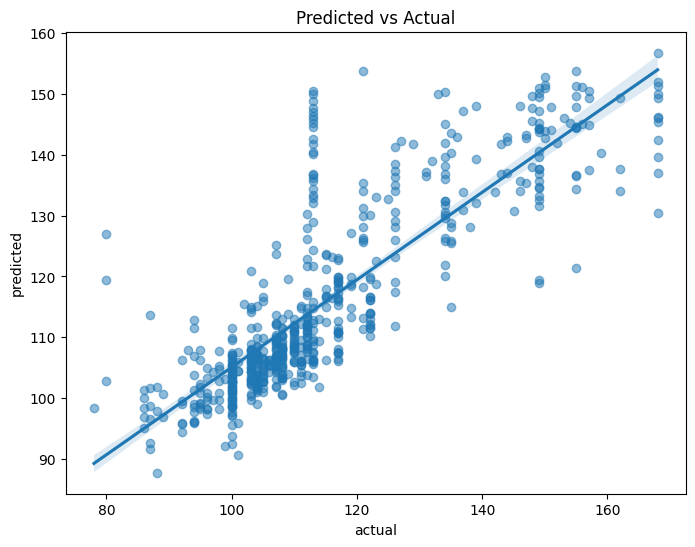

In [43]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_m, y_holdout_m)

In [44]:
explainer = shap.Explainer(best_xgbr_model)

In [45]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

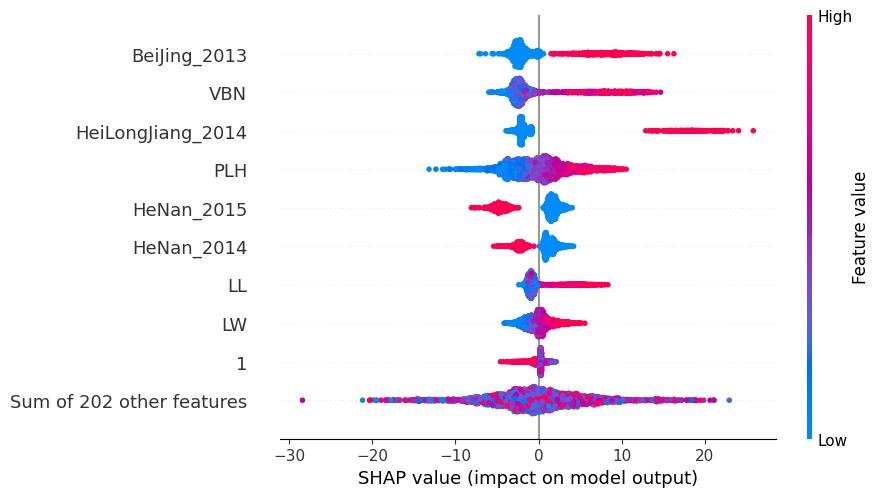

In [46]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

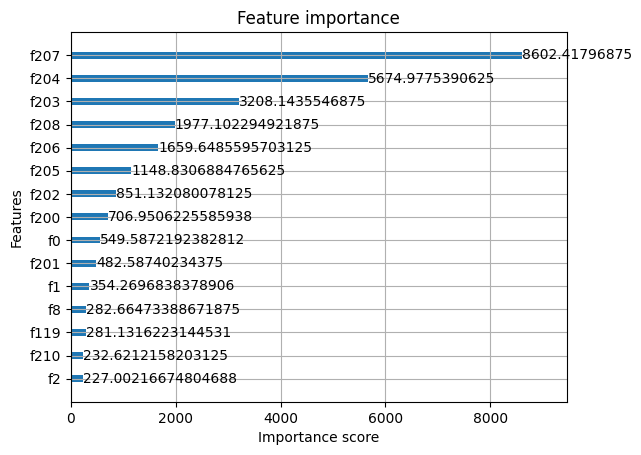

In [47]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

#### RF models

In [48]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 45), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [183]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [ ]:
#best_rfreg = OrderedDict([('bootstrap', True), 
                          ('max_depth', 45), 
                          ('max_features', 'sqrt'), 
                          ('max_samples', 1.0), 
                          ('min_samples_leaf', 1), 
                          ('min_samples_split', 2), 
                          ('n_estimators', 500)])

In [49]:
best_rfr_model = eval_k_fold(best_rfreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.07249081774079136
RMSE for dataset is:11.126629430693818& mean of this fold is 116.7673469387755
this is 9.528887760486526% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.3519533813434699
RMSE for dataset is:9.566698079517982& mean of this fold is 117.30204081632652
this is 8.15561094499428% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.126413532026307
RMSE for dataset is:10.701651499098785& mean of this fold is 115.33877551020409
this is 9.278450765373353% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.19829168761239135
RMSE for dataset is:10.414744675365846& mean of this fold is 116.43673469387755
this is 8.944552338011821% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.17138164303986947
RMSE for da

In [184]:
X = X.to_numpy()
y = y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.611343604730705
RMSE for dataset is:9.599791147232587& mean of this fold is 115.17142857142858
this is 8.335219304220802% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5687113642565074
RMSE for dataset is:10.574428817252127& mean of this fold is 117.06938775510204
this is 9.032616484996762% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5301280271919244
RMSE for dataset is:10.965008765064947& mean of this fold is 117.06122448979592
this is 9.36690079302968% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5677576529280767
RMSE for dataset is:10.534195345294512& mean of this fold is 117.9469387755102
this is 8.931300341202046% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5964208746971922
RMSE for datas

In [50]:
pickle.dump(best_rfr_model, open("pca_200_best_model_allfeats_rfr_md.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_200_best_model_allfeats_rfr_md.pickle.dat", "rb"))

In [185]:
pickle.dump(best_svr_model, open("pca_200_best_model_allfeats_svr_md.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_200_best_model_allfeats_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: 0.04
RMSE of Holdout: 11.10
Mean of Holdout: 115.12
This is 9.64% of the mean pheno data
0 117.0 127.35
1 115.0 120.776
2 100.0 101.668
3 107.0 105.298
4 168.0 132.568
5 150.0 137.878


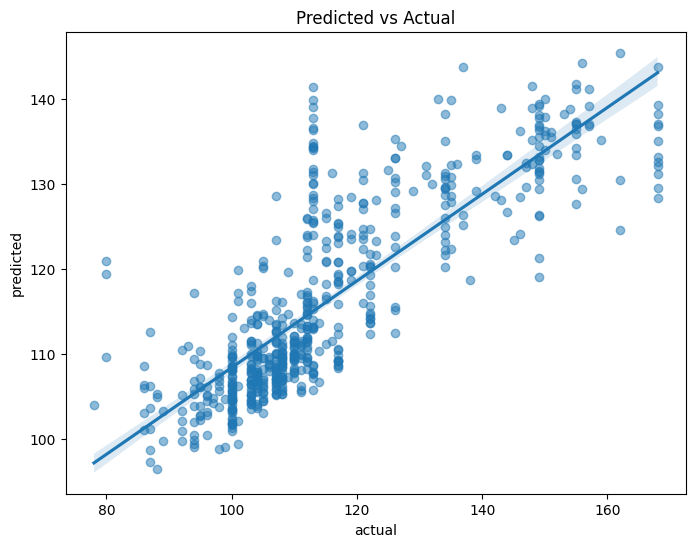

In [51]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_m, y_holdout_m)

R^2 Value of Holdout: 0.58
RMSE of Holdout: 10.42
Mean of Holdout: 115.12
This is 9.05% of the mean pheno data
0 117.0 119.4894724160933
1 115.0 114.48653804366968
2 100.0 99.75210073494573
3 107.0 104.05724753978639
4 168.0 134.44466093740556
5 150.0 140.867893907344


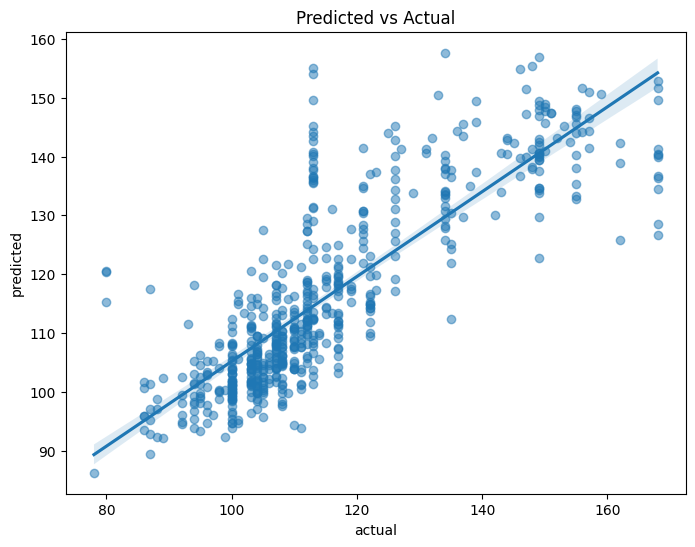

In [186]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_m, y_holdout_m)

## PC500 Models

In [187]:
y = pca_full_train_m.iloc[:, 511:]
y.head()

,MD
Line,
s503,113.0
s2833,107.0
s1616,100.0
s833,103.0
s265,103.0


In [188]:
X = pca_full_train_m.iloc[:, 0:511]
X.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [189]:
X_dupe = pca_full_train_m.iloc[:, 0:511]
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s503,-0.013944,0.001634,0.015458,-0.005624,-0.027454,0.047615,0.000549,0.015527,0.045923,-0.000988,...,6.60000,43.9333,5.33333,1,0,0,0,0,0,1
s2833,0.005817,0.020205,-0.021799,-0.014568,-0.020317,-0.045931,0.000296,0.006642,0.009438,-0.009443,...,5.54667,83.2000,1.40000,0,0,1,0,0,1,0
s1616,-0.022925,0.037485,-0.003663,0.042498,0.032951,-0.014113,-0.006930,-0.009058,0.030347,0.025450,...,8.32000,60.8000,3.80000,0,0,1,0,0,1,0
s833,0.021951,0.016145,-0.018782,-0.002036,0.057344,0.028400,0.011714,0.016359,-0.004302,-0.004019,...,3.78000,67.0000,0.80000,0,1,0,0,0,1,0
s265,-0.068787,-0.047301,0.000729,-0.004077,0.014950,0.007643,0.013510,0.024539,0.004857,-0.025671,...,7.43333,79.0000,1.00000,0,1,0,0,0,1,0


In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [191]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [58]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5081000335874989), ('colsample_bytree', 0.7518972045934136), ('gamma', 6.467045058726481e-07), ('learning_rate', 0.08922553947589419), ('max_delta_step', 17), ('max_depth', 25), ('min_child_weight', 6), ('n_estimators', 78), ('reg_alpha', 0.20214922576590433), ('reg_lambda', 1.2508318503832269e-08), ('subsample', 0.8843482587346397)])


In [ ]:
#best_xgbreg = OrderedDict([('colsample_bylevel', 0.5081000335874989), 
                           ('colsample_bytree', 0.7518972045934136), 
                           ('gamma', 6.467045058726481e-07), 
                           ('learning_rate', 0.08922553947589419), 
                           ('max_delta_step', 17), 
                           ('max_depth', 25), 
                           ('min_child_weight', 6), 
                           ('n_estimators', 78), 
                           ('reg_alpha', 0.20214922576590433), 
                           ('reg_lambda', 1.2508318503832269e-08), 
                           ('subsample', 0.8843482587346397)])

In [59]:
X = X.to_numpy()
y = y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6021660546997093
RMSE for dataset is:10.607474750563254& mean of this fold is 117.42448979591836
this is 9.033443337926231% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5628690006910042
RMSE for dataset is:10.010229740541313& mean of this fold is 116.15102040816326
this is 8.618288246943182% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6843709256614187
RMSE for dataset is:8.751003863501547& mean of this fold is 116.14081632653061
this is 7.534822072283396% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.616114734278875
RMSE for dataset is:9.266151165040608& mean of this fold is 117.56734693877551
this is 7.881568655169244% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5972066858093037
RMSE for data

In [60]:
pickle.dump(best_xgbr_model, open("pca_500_best_model_allfeats_xgbr_md.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_allfeats_xgbr_md.pickle.dat", "rb"))

In [192]:
pca_full_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,MD
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,94.8000,1.40000,0,0,0,0,1,1,0,117.0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,120.8000,2.80000,0,0,1,0,0,0,1,115.0
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,60.4000,1.60000,0,1,0,0,0,1,0,100.0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,63.0000,1.80000,0,1,0,0,0,0,1,107.0
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,97.1667,4.33333,1,0,0,0,0,0,1,168.0


In [193]:
X_holdout_m = pca_full_holdout_m.iloc[:, :511]
X_holdout_m.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2692,0.030738,-0.005767,-0.011790,-0.049442,0.032766,-0.016851,-0.023386,-0.016504,0.005044,-0.006670,...,4.96600,94.8000,1.40000,0,0,0,0,1,1,0
s131,-0.014971,0.039177,0.002477,-0.018919,-0.014087,-0.028447,-0.039452,-0.042739,-0.028440,0.038526,...,6.11333,120.8000,2.80000,0,0,1,0,0,0,1
s272,0.037445,-0.018413,0.027431,-0.081640,0.074583,-0.019641,-0.031620,-0.034705,0.023780,0.003327,...,4.19333,60.4000,1.60000,0,1,0,0,0,1,0
s344,-0.078112,-0.052469,-0.001623,-0.013879,0.024389,-0.009267,0.032115,0.035926,-0.017821,-0.049911,...,7.30667,63.0000,1.80000,0,1,0,0,0,0,1
s324,0.005737,0.011026,0.017319,-0.034853,-0.036881,0.039449,-0.000579,-0.009294,0.045854,-0.018372,...,6.93333,97.1667,4.33333,1,0,0,0,0,0,1


In [194]:
y_holdout_m = pca_full_holdout_m.iloc[:, 511:]
y_holdout_m.head()

,MD
Line,
s2692,117.0
s131,115.0
s272,100.0
s344,107.0
s324,168.0


In [195]:
X_holdout_m = X_holdout_m.to_numpy()
y_holdout_m = y_holdout_m.to_numpy()

R^2 Value of Holdout: 0.57
RMSE of Holdout: 10.16
Mean of Holdout: 115.12
This is 8.83% of the mean pheno data
0 117.0 120.30077
1 115.0 110.381935
2 100.0 101.470314
3 107.0 104.65506
4 168.0 144.1291
5 150.0 149.19913


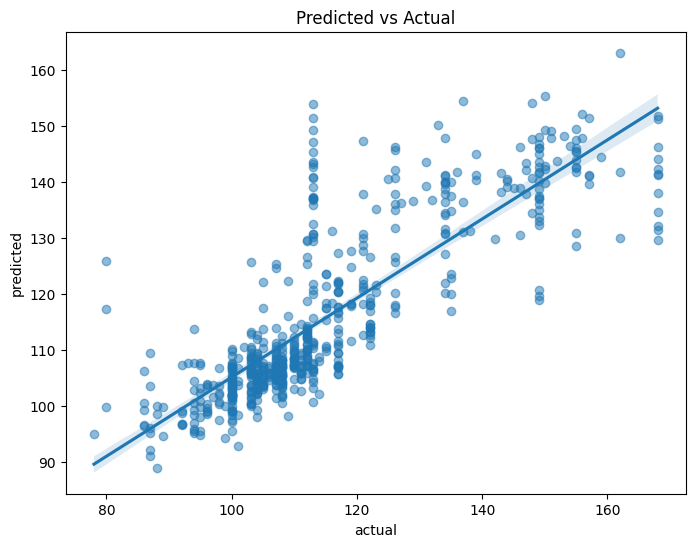

In [65]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout_m, y_holdout_m)

In [66]:
explainer = shap.Explainer(best_xgbr_model)

In [67]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

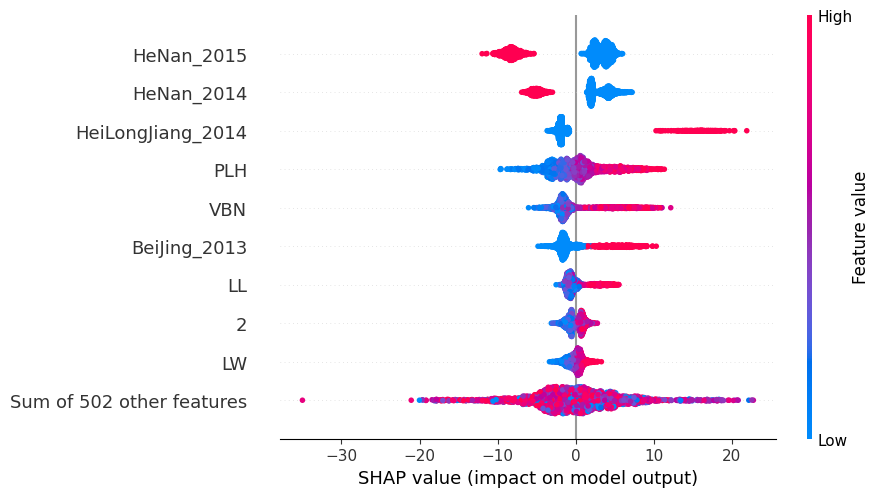

In [68]:
shap.plots.beeswarm(shap_values, show=False)

<Figure size 2000x2000 with 0 Axes>

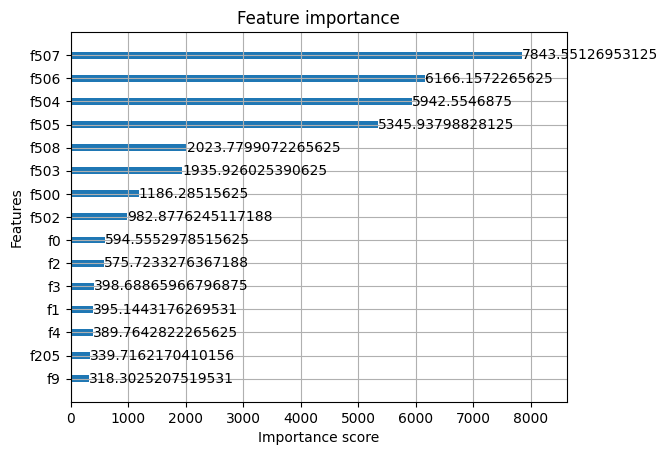

In [69]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [70]:
#### RF Models

In [71]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 46), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 500)])


In [196]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [ ]:
best_rfreg = OrderedDict([('bootstrap', True), 
                          ('max_depth', 46), 
                          ('max_features', 'sqrt'), 
                          ('max_samples', 1.0), 
                          ('min_samples_leaf', 1), 
                          ('min_samples_split', 2), 
                          ('n_estimators', 500)])

In [72]:
best_rfr_model = eval_k_fold(best_rfreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5707871951247612
RMSE for dataset is:12.00694700035724& mean of this fold is 117.2734693877551
this is 10.238417148432145% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5196110180786475
RMSE for dataset is:12.5479330289441& mean of this fold is 118.2530612244898
this is 10.611085158398813% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.4393605660890192
RMSE for dataset is:11.678665613444782& mean of this fold is 115.04897959183674
this is 10.151037979543661% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.7078507388574644
RMSE for dataset is:13.057464639986193& mean of this fold is 116.71836734693878
this is 11.187154975509223% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.48125745207605
RMSE for

In [197]:
X = X.to_numpy()
y = y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, X, y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5724238557234689
RMSE for dataset is:10.148605314738983& mean of this fold is 117.32244897959184
this is 8.650181958360182% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5343765578310641
RMSE for dataset is:10.981637063605323& mean of this fold is 116.71836734693878
this is 9.40866233243567% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5136470839268205
RMSE for dataset is:10.66537677758515& mean of this fold is 117.56326530612245
this is 9.072031769289177% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.5337490175268558
RMSE for dataset is:11.163026378296562& mean of this fold is 115.62040816326531
this is 9.654892726665928% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.639934076775138
RMSE for data

In [73]:
pickle.dump(best_rfr_model, open("pca_500_best_model_allfeats_rfr_md.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_allfeats_rfr_md.pickle.dat", "rb"))

In [198]:
pickle.dump(best_svr_model, open("pca_500_best_model_allfeats_svr_md.pickle.dat", "wb"))
#best_rfr_model = pickle.load(open("pca_500_best_model_allfeats_rfr_md.pickle.dat", "rb"))

R^2 Value of Holdout: -0.47
RMSE of Holdout: 12.19
Mean of Holdout: 115.12
This is 10.59% of the mean pheno data
0 117.0 130.874
1 115.0 124.15
2 100.0 102.346
3 107.0 105.91
4 168.0 130.062
5 150.0 135.222


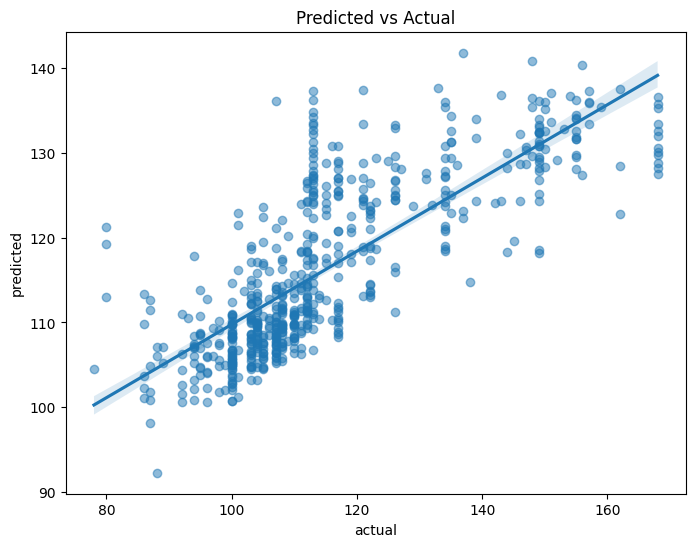

In [74]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout_m, y_holdout_m)

R^2 Value of Holdout: 0.58
RMSE of Holdout: 10.36
Mean of Holdout: 115.12
This is 8.99% of the mean pheno data
0 117.0 119.26667074022559
1 115.0 114.25802869565602
2 100.0 100.6064179211077
3 107.0 103.9257056471403
4 168.0 134.59960827483218
5 150.0 142.00436136088837


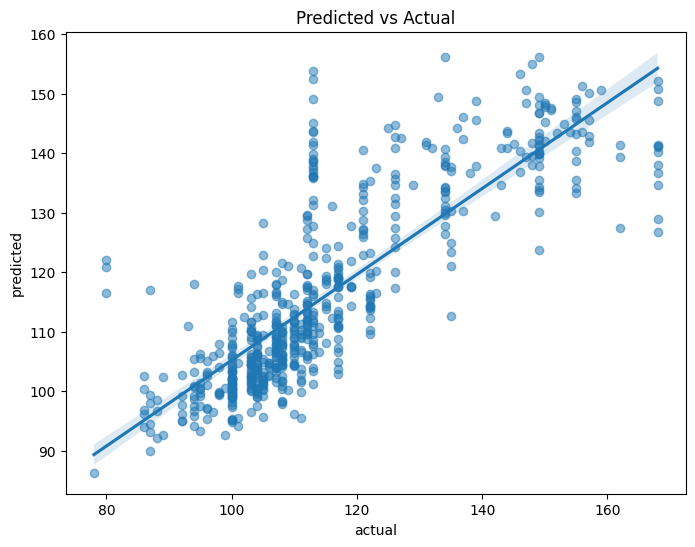

In [199]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout_m, y_holdout_m)

# Protein content (PRT) models

## Load and process the data

In [ ]:
pca_full_train_p = pd.read_pickle("pickle_files/pca_full_training_prt.pkl")

In [ ]:
pca_full_train_p = pca_full_train_p.reset_index().set_index('Line')
pca_full_train_p = pca_full_train_p.drop(['index','new_line'], axis=1)
pca_full_train_p.head()

In [ ]:
pca_full_holdout_p = pd.read_pickle("pickle_files/pca_full_holdout_prt.pkl")

In [ ]:
pca_full_holdout_p = pca_full_holdout_p.reset_index().set_index('Line')
pca_full_holdout_p = pca_full_holdout_p.drop(['index','new_line'], axis=1)
pca_full_holdout_p.head()